# Project Checkpoint 1: Dataset Comparison, Selection, and EDA



## (A) Identification of Candidate Datasets



### 1) Amazon Reviews 2023
- **Dataset name:** Amazon Reviews 2023 (McAuley Lab)
- **Source:** https://amazon-reviews-2023.github.io/
- **Course topic:**
  - Text mining (embeddings, similarity, clustering)
  - Graph mining
- **Beyond course techniques:**
  - Recommender models
  - Topic modeling
  - Transformer embeddings
- **Dataset size and structure:** Large-scale. reviews, item metadata, optional link/graph files (size depends on chosen categories)
- **Data types:** Review text, ratings, user IDs, item IDs, timestamps, helpfulness
- **Target variables:** Rating or helpfulness (supervised), topics/clusters (unsupervised)
- **Licensing/constraints:** Public research dataset while follow the site’s citation and usage instructions

---

### 2) NYC TLC Trip Record Data
- **Dataset name:** NYC TLC Trip Record Data  
- **Source:** https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
- **Course topic:**
  - Clustering (trip/zone patterns)
  - Anomaly detection (outlier trips: fare, duration, speed)
  - Graph mining (zone-to-zone flow graph)
- **Beyond course techniques:**
  - Spatiotemporal forecasting (demand per zone/hour)
  - Graph-based forecasting
- **Dataset size and structure:** Very large; seperated into monthly parquet files by service type (Yellow/Green/FHV). Each row is one trip record.
- **Data types:** Pickup/dropoff timestamps, pickup/dropoff location IDs, trip distance, fare/tip/tolls, passenger count, payment type/vendor
- **Target variables:** Trip duration or fare (supervised), demand counts per zone/time (supervised), anomaly detection (unsupervised)
- **Licensing/constraints:** Public data. Must cite TLC.
---

### 3) CIC-IDS2017
- **Dataset name:** CIC-IDS2017 (Canadian Institute for Cybersecurity, UNB)
- **Source:** https://www.unb.ca/cic/datasets/ids-2017.html
- **Course topic:**
  - Anomaly detection
  - Clustering
  - Streams framing
- **Beyond course techniques:**
  - Autoencoder-based anomaly detection
  - Domain shift evaluation (train on some days, test on others)
- **Dataset size and structure:** Large; labeled network flow CSVs. Multiple days and attack scenarios.
- **Data types:** Flow feature vectors (numeric), protocol/flag features, timestamps, labels (benign/attack + attack type)
- **Target variables:** Multiclass attack classification (supervised), anomaly detection (unsupervised)
- **Licensing/constraints:** Public research dataset. Must cite the CIC paper per dataset.

<h2>(B) Comparative Analysis of Datasets</h2>

<table style="width:100%; font-size:1em, line-height:1.35, border-collapse:collapse, table-layout:fixed;">
  <thead>
    <tr>
      <th style="border:1px solid #999, padding:0.75em 0.85em, font-size:1em, background:#f2f2f2;">Dimension</th>
      <th style="border:1px solid #999, padding:0.75em 0.85em, font-size:1em, background:#f2f2f2;">Amazon Reviews 2023</th>
      <th style="border:1px solid #999, padding:0.75em 0.85em, font-size:1em, background:#f2f2f2;">NYC TLC Trips</th>
      <th style="border:1px solid #999, padding:0.75em 0.85em, font-size:1em, background:#f2f2f2;">CIC-IDS2017</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Supported tasks<br>(course and beyond)</b></td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Course:</b> text mining, clustering, <i></i> graph.<br><b>Beyond:</b> topic modeling, transformers, recommenders.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Course:</b> clustering, anomaly, <i></i> flow-graph.<br><b>Beyond:</b> spatiotemporal + graph forecasting.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Course:</b> anomaly, clustering, streams framing.<br><b>Beyond:</b> autoencoder anomalies, domain shift analysis</td>
    </tr>
    <tr>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Data quality issues</b></td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Noisy text, missing fields by category, duplicates.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Invalid 0/negative values, outliers, missing orunknown location IDs.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Redundant features, label noise, class imbalance.</td>
    </tr>
    <tr>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Algorithmic feasibility</b></td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Subset categories, batch embeddings, filter rare users/items.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Restrict months, use parquet, aggregate early (zone-hour), forecasting feasible on aggregates.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Feature selection and minibatching, GPU optional, time/day splits required for validity.</td>
    </tr>
    <tr>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Bias considerations</b></td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Self selection, recommender bias, language skew.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">NYC only, measurement bias by vendor/zone/time, shocks from events/policies.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Testbed realism limits, attack mix differs by day, benign diversity limited.</td>
    </tr>
    <tr>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;"><b>Ethical considerations</b></td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Avoid deanonymization, reviews may include personal info, no individual profiling.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Avoid re-identification, avoid stigmatizing neighborhoods.</td>
      <td style="border:1px solid #999, padding:0.75em 0.85em, vertical-align:top;">Defensive use only, false positives have real world harm.</td>
    </tr>
  </tbody>
</table>


## (C) Dataset Selection



### Selected dataset: NYC TLC Trip Record Data

#### Reasons:
-  This is the most fun dataset to me because I’ve worked on an ML project where geospatial data was important, and I enjoy having that rea world geographic context.
- From the course, I can use clustering to discover patterns in how people like to move arounf the city and anomaly detection to flag suspicious or inconsistent records.
- From beyond the course I am excited to learn about demand forecasting using zones and time. This is something I have always been interested in when it came to ride share companies.
- Because the data is messy and large-scale, I believe this can become a strong portfolio project.

#### Trade offs:
- The dataset is massive, so I will need to scope it. I will need to reduce size by only chosing one service and reduce the number of months.
- Since it is NYC specifc, any conclusions would only be about this system and most likely couldnt be generalized.

## (D) Exploratory Data Analysis (Selected Dataset Only)

### Downloading the dataset for a configurable month/year range

Use `DATA_START` `DATA_END` (format `YYYY-MM`) to set the range of data to be downloaded. The downloader will download each monthly parquet file for the data range if it exists. `SAMPLE_ROWS_PER_MONTH` downsamples the Parquet file for each month to make RAM usage more managable.


In [19]:
# data-range configuration
DATA_START = "2025-01"
DATA_END   = "2025-11"

# set to an integer (something like 500_000) to downsample each month after loading. Use None to keep the full siz
SAMPLE_ROWS_PER_MONTH = 1_500_000
RANDOM_STATE = 412

# This is to control the removal of exact duplicates
DO_DEDUP = True

import pandas as pd
from pathlib import Path

# print the range used in this analysis
PERIODS = pd.period_range(DATA_START, DATA_END, freq="M")
print(f"Configured period range: {PERIODS[0]} → {PERIODS[-1]} ({len(PERIODS)} months)")


Configured period range: 2025-01 → 2025-11 (11 months)


In [20]:
#download monthly Yellow Taxi parquet file

import os
from pathlib import Path
import urllib.request

BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
OUT_BASE = Path("data/nyc_tlc/yellow")
OUT_BASE.mkdir(parents=True, exist_ok=True)

def download_dataset(url: str, to_path: Path):
    to_path.parent.mkdir(parents=True, exist_ok=True)

    if to_path.exists() and to_path.stat().st_size > 0:
        print(f"!!! Already exists: {to_path.name} !!!")
        return

    print(f"Downloading from {url} ...")
    try:
        urllib.request.urlretrieve(url, str(to_path))
        size = to_path.stat().st_size / (1024 * 1024)
        print(f"Saved to {to_path} ({size:.2f} MB)")
    except Exception as e:
        # TLC doesnt always have all month
        print(f"Download failed for {to_path.name}: {e}")

for p in PERIODS:
    year, month = int(p.year), int(p.month)
    ym = f"{year}-{month:02d}"
    fname = f"yellow_tripdata_{ym}.parquet"

    dest = OUT_BASE / str(year) / fname
    url = f"{BASE_URL}/{fname}"

    download_dataset(url, dest)

print(f"Done. Files saved under: {OUT_BASE.resolve()}")


!!! Already exists: yellow_tripdata_2025-01.parquet !!!
!!! Already exists: yellow_tripdata_2025-02.parquet !!!
!!! Already exists: yellow_tripdata_2025-03.parquet !!!
!!! Already exists: yellow_tripdata_2025-04.parquet !!!
!!! Already exists: yellow_tripdata_2025-05.parquet !!!
!!! Already exists: yellow_tripdata_2025-06.parquet !!!
!!! Already exists: yellow_tripdata_2025-07.parquet !!!
!!! Already exists: yellow_tripdata_2025-08.parquet !!!
!!! Already exists: yellow_tripdata_2025-09.parquet !!!
!!! Already exists: yellow_tripdata_2025-10.parquet !!!
!!! Already exists: yellow_tripdata_2025-11.parquet !!!
Done. Files saved under: /content/data/nyc_tlc/yellow


### 1) Load the dataset/Structure view + Simple cleaning.

In [21]:
# Load TLC Yellow Taxi parquet files into a single DataFrame
import numpy as np

# 1. Build file list for specific range
files = []
for p in PERIODS:
    year, month = int(p.year), int(p.month)
    f = Path(f"data/nyc_tlc/yellow/{year}/yellow_tripdata_{year}-{month:02d}.parquet")
    files.append(f)

missing = [str(f) for f in files if not f.exists()]
if missing:
    raise FileNotFoundError(
        "Missing one or more monthly files. Run the download cell above first.\n"
        + "\n".join(missing[:10])
        + (f"\n... and {len(missing)-10} more" if len(missing) > 10 else "")
    )

# Optional: this keeps memory lower fall back to full read if columns differ
USE_COLUMNS = [
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
]

dfs = []
for f in files:
    try:
        df = pd.read_parquet(f, columns=USE_COLUMNS)
    except Exception:
        df = pd.read_parquet(f)
        keep = [c for c in USE_COLUMNS if c in df.columns]
        df = df[keep] if keep else df

    if SAMPLE_ROWS_PER_MONTH is not None and len(df) > SAMPLE_ROWS_PER_MONTH:
        df = df.sample(SAMPLE_ROWS_PER_MONTH, random_state=RANDOM_STATE)

    df["source_month"] = f.stem.replace("yellow_tripdata_", "")
    dfs.append(df)

taxi_raw = pd.concat(dfs, ignore_index=True)

print("Shape:", taxi_raw.shape)
print("\nColumns:", list(taxi_raw.columns))

print("\n--- Info ---")
taxi_raw.info()

print("\n--- Random sample ---")
display(taxi_raw.sample(5, random_state=RANDOM_STATE))

# empty columns
empty_cols = []
for col in taxi_raw.columns:
    s = taxi_raw[col]
    if s.isnull().all():
        empty_cols.append(col)
    elif (s.dtype == "object" or pd.api.types.is_string_dtype(s)) and s.astype("string").str.strip().fillna("").eq("").all():
        empty_cols.append(col)

print("\nempty cols:", empty_cols if len(empty_cols) > 0 else "none")

# test to make sure all core collumns exist
expected_cols = {"tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID", "trip_distance", "fare_amount", "total_amount"}
assert len(taxi_raw) > 0, "taxi_raw is empty; load failed"
assert expected_cols.issubset(set(taxi_raw.columns)), f"Missing expected columns: {expected_cols - set(taxi_raw.columns)}"
print("Load tests passed")


Shape: (16500000, 21)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'source_month']

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16500000 entries, 0 to 16499999
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,source_month
11203433,2,2025-08-24 02:41:36,2025-08-24 02:49:00,1.0,1.88,1.0,N,148,137,1,...,1.0,0.5,3.29,0.0,1.0,19.74,2.5,0.0,0.75,2025-08
7046056,2,2025-05-13 10:37:53,2025-05-13 10:45:33,1.0,1.37,1.0,N,236,141,1,...,0.0,0.5,2.66,0.0,1.0,15.96,2.5,0.0,0.00,2025-05
8495458,2,2025-06-15 12:48:20,2025-06-15 13:03:03,NaN,2.59,NaN,None,75,42,0,...,0.0,0.5,0.00,0.0,1.0,17.10,NaN,NaN,0.00,2025-06
660139,2,2025-01-11 16:41:04,2025-01-11 16:50:05,1.0,0.98,1.0,N,43,230,2,...,0.0,0.5,0.00,0.0,1.0,14.75,2.5,0.0,0.75,2025-01
11121174,2,2025-08-20 19:12:17,2025-08-20 19:29:21,NaN,0.00,NaN,None,249,232,0,...,0.0,0.5,0.00,0.0,1.0,3.01,NaN,NaN,0.75,2025-08



empty cols: none
Load tests passed


Key columns and what they mean:

<table> <thead> <tr> <th>Column</th> <th>Type</th> <th>What it is</th> </tr> </thead> <tbody> <tr><td>VendorID</td><td>Nominal</td><td>Taxi provider ID (label)</td></tr> <tr><td>tpep_pickup_datetime</td><td>Datetime</td><td>Pickup timestamp</td></tr> <tr><td>tpep_dropoff_datetime</td><td>Datetime</td><td>Dropoff timestamp</td></tr> <tr><td>passenger_count</td><td>Numeric</td><td>Passenger count</td></tr> <tr><td>trip_distance</td><td>Numeric</td><td>Distance (miles)</td></tr> <tr><td>RatecodeID</td><td>Nominal</td><td>Rate code category</td></tr> <tr><td>store_and_fwd_flag</td><td>Nominal</td><td>Store/forward flag (Y/N)</td></tr> <tr><td>PULocationID</td><td>Nominal</td><td>Pickup zone ID (label)</td></tr> <tr><td>DOLocationID</td><td>Nominal</td><td>Dropoff zone ID (label)</td></tr> <tr><td>payment_type</td><td>Nominal</td><td>Payment method</td></tr> <tr><td>fare_amount</td><td>Numeric</td><td>Fare amount (&#36;)</td></tr> <tr><td>tip_amount</td><td>Numeric</td><td>Tip amount (&#36;)</td></tr> <tr><td>total_amount</td><td>Numeric</td><td>Total charge (&#36;)</td></tr> </tbody> </table>

In [22]:
# Clean and type conversions
taxi = taxi_raw.copy()

# drop all fully empty collumns
taxi = taxi.drop(columns=[c for c in empty_cols if c in taxi.columns])

# drop any 'unnamed' columns
unamed_cols = [c for c in taxi.columns if str(c).strip().lower().startswith("unnamed")]
if unamed_cols:
    taxi = taxi.drop(columns=unamed_cols)

# Parse datetimes (errors='coerce')
for col in ["tpep_pickup_datetime", "tpep_dropoff_datetime"]:
    if col in taxi.columns:
        taxi[col] = pd.to_datetime(taxi[col], errors="coerce")

# Coerce numerics (errors='coerce')
numeric_cols = [
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
]
for col in numeric_cols:
    if col in taxi.columns:
        taxi[col] = pd.to_numeric(taxi[col], errors="coerce")

#standardize text flags
if "store_and_fwd_flag" in taxi.columns:
    taxi["store_and_fwd_flag"] = taxi["store_and_fwd_flag"].astype("string").str.strip().str.lower()


# Basic validity filters and row loss checking
n_raw = len(taxi)

# passenger count should be 0 to 6 for yellow taxi (0 can appear for missing of unkown)
if "passenger_count" in taxi.columns:
    pc_good = taxi["passenger_count"].isna() | taxi["passenger_count"].between(0, 6)
else:
    pc_good = True

# Distances and amounts should not be negative
dist_good = taxi["trip_distance"].isna() | (taxi["trip_distance"] >= 0) if "trip_distance" in taxi.columns else True

amt_cols = [c for c in ["fare_amount","total_amount","tip_amount","tolls_amount"] if c in taxi.columns]
amt_good = True
for c in amt_cols:
    amt_good = amt_good & (taxi[c].isna() | (taxi[c] >= 0))

taxi = taxi[pc_good & dist_good & amt_good].copy()
n_after_basic = len(taxi)

# dropoff must be >= picku
if {"tpep_pickup_datetime","tpep_dropoff_datetime"}.issubset(taxi.columns):
    time_good = (
        taxi["tpep_pickup_datetime"].isna()
        | taxi["tpep_dropoff_datetime"].isna()
        | (taxi["tpep_dropoff_datetime"] >= taxi["tpep_pickup_datetime"])
    )
    taxi = taxi[time_good].copy()

n_after_time = len(taxi)

# drop exact duplicatess
if DO_DEDUP:
    taxi = taxi.drop_duplicates()

n_after_dedup = len(taxi)

print(f"Cleaned taxi: {taxi.shape[0]:,} rows x {taxi.shape[1]:,} cols")
print(
    f"Row-loss accounting: dropped {n_raw - n_after_dedup:,} total "
    f"(basic validity: {n_raw - n_after_basic:,}, time: {n_after_basic - n_after_time:,}, dups: {n_after_time - n_after_dedup:,})"
)


# Tests:
if "passenger_count" in taxi.columns:
    assert taxi["passenger_count"].dropna().between(0, 6).all(), "passenger count is out of bounds"
if "trip_distance" in taxi.columns:
    assert (taxi["trip_distance"].dropna() >= 0).all(), "trip distance is out of bounds"
for c in amt_cols:
    assert (taxi[c].dropna() >= 0).all(), f"{c} contains negative values after cleaning"

if {"tpep_pickup_datetime","tpep_dropoff_datetime"}.issubset(taxi.columns):
    tmp = taxi.dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime"])
    assert (tmp["tpep_dropoff_datetime"] >= tmp["tpep_pickup_datetime"]).all(), "there is a dropoff before pickup"

if DO_DEDUP:
    assert not taxi.duplicated().any(), "there are still some duplicate rows"

print("all cleaning tests passed")

# Keep these variables for later cells
n_after_pc_dist = n_after_basic
dropped_pc_dist = n_raw - n_after_basic
n_after_time = n_after_time
dropped_time = n_after_basic - n_after_time
n_after_dedup = n_after_dedup
dropped_dups = n_after_time - n_after_dedup


Cleaned taxi: 15,467,200 rows x 21 cols
Row-loss accounting: dropped 1,032,800 total (basic validity: 1,031,988, time: 812, dups: 0)
all cleaning tests passed


### 2) Missingness checks

In [23]:
# Missingness and rowloss summary
print("\n" + "-" * 120)
print("Missing values (raw) — top 10 by %:")

missing_raw = taxi_raw.isna().mean().sort_values(ascending=False)
display((missing_raw * 100).head(10).round(2).astype(str) + "%")

print("\n" + "-" * 120)
print("Missing values (cleaned) — top 10 by %:")

missing_clean = taxi.isna().mean().sort_values(ascending=False)
display((missing_clean * 100).head(10).round(2).astype(str) + "%")

# #missingness table
# print("\n" + "-" * 120)
# print("Missingness table (raw):")
# missing_table_raw = (
#     taxi_raw.isna().sum()
#       .to_frame("missing_count")
#       .assign(missing_pct=lambda x: (x["missing_count"] / len(taxi_raw) * 100).round(2))
#       .sort_values("missing_count", ascending=False)
# )
# display(missing_table_raw)

# print("\n" + "-" * 120)
# print("Missingness table (cleaned):")
# missing_table_clean = (
#     taxi.isna().sum()
#       .to_frame("missing_count")
#       .assign(missing_pct=lambda x: (x["missing_count"] / len(taxi) * 100).round(2))
#       .sort_values("missing_count", ascending=False)
# )
# display(missing_table_clean)

# Row loss summary
print("\n" + "-" * 120)
print("What did we lose? (row loss summary):")

n_clean = len(taxi)
dropped_total = n_raw - n_clean

print(f"Raw rows: {n_raw:,}")
print(f"After basic validity filters: {n_after_pc_dist:,}  (dropped: {dropped_pc_dist:,})")
print(f"After time-order filter: {n_after_time:,}  (dropped: {dropped_time:,})")
if DO_DEDUP:
    print(f"After exact dedup: {n_after_dedup:,}  (dropped: {dropped_dups:,})")
else:
    print("After exact dedup: (skipped)")
print(f"Final cleaned rows: {n_clean:,}  (total dropped: {dropped_total:,})")

# Tests: row accounting should match the cleaning
assert n_after_dedup == n_clean, "Row counts don't match"
assert dropped_total == (dropped_pc_dist + dropped_time + dropped_dups), "Dropped counts don't sum to total dropped"
print("Row-loss tests passed")



------------------------------------------------------------------------------------------------------------------------
Missing values (raw) — top 10 by %:


,0
passenger_count,23.28%
Airport_fee,23.28%
congestion_surcharge,23.28%
store_and_fwd_flag,23.28%
RatecodeID,23.28%
trip_distance,0.0%
tpep_dropoff_datetime,0.0%
tpep_pickup_datetime,0.0%
VendorID,0.0%
payment_type,0.0%



------------------------------------------------------------------------------------------------------------------------
Missing values (cleaned) — top 10 by %:


,0
passenger_count,19.99%
Airport_fee,19.99%
congestion_surcharge,19.99%
store_and_fwd_flag,19.99%
RatecodeID,19.99%
trip_distance,0.0%
tpep_dropoff_datetime,0.0%
tpep_pickup_datetime,0.0%
VendorID,0.0%
payment_type,0.0%



------------------------------------------------------------------------------------------------------------------------
What did we lose? (row loss summary):
Raw rows: 16,500,000
After basic validity filters: 15,468,012  (dropped: 1,031,988)
After time-order filter: 15,467,200  (dropped: 812)
After exact dedup: 15,467,200  (dropped: 0)
Final cleaned rows: 15,467,200  (total dropped: 1,032,800)
Row-loss tests passed


In my sample of the data (Jan–Nov 2025), the same five fields are missing for **23.28%** of trips:  
`passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee`.

After basic cleaning, the missingness for these five fields drops to **19.99%**, but this is because invalid rows were removed.


### 3) Decoding the categorical codes

There are several columns that are numeric codes. Decoding them for the EDA for readability and plot making.

Reference: NYC TLC Trip Record Data Dictionary (Yellow Taxi).

In [24]:
# TLC codebooks (Yellow Taxi)
# Source: TLC trip record data dictionary
ratecode_map = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride"
}

payment_type_map = {
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

store_and_fwd_map = {
    "y": "Store-and-forward",
    "n": "Not store-and-forward"
}

taxi["Ratecode_name"] = taxi["RatecodeID"].map(ratecode_map).astype("string").fillna("Unknown")
taxi["payment_type_name"] = taxi["payment_type"].map(payment_type_map).astype("string").fillna("Unknown")
taxi["store_and_fwd_name"] = taxi["store_and_fwd_flag"].map(store_and_fwd_map).astype("string").fillna("Unknown")

display(taxi[["RatecodeID","Ratecode_name","payment_type","payment_type_name","store_and_fwd_flag","store_and_fwd_name"]].sample(10))


,RatecodeID,Ratecode_name,payment_type,payment_type_name,store_and_fwd_flag,store_and_fwd_name
12093798,1.0,Standard rate,2,Cash,n,Not store-and-forward
9511134,1.0,Standard rate,2,Cash,y,Store-and-forward
1100050,1.0,Standard rate,1,Credit card,n,Not store-and-forward
11996883,1.0,Standard rate,1,Credit card,n,Not store-and-forward
10487529,1.0,Standard rate,1,Credit card,n,Not store-and-forward
3206919,NaN,Unknown,0,Unknown,<NA>,Unknown
9697758,NaN,Unknown,0,Unknown,<NA>,Unknown
2918040,1.0,Standard rate,1,Credit card,n,Not store-and-forward
6528838,1.0,Standard rate,1,Credit card,n,Not store-and-forward
7936781,NaN,Unknown,0,Unknown,<NA>,Unknown


### 4) Taxi Zone Lookup (LocationID → Borough/Zone)

Similar to the previous section, the code cells below will transform the location IDs into readible borough/zone to see spatial patterns without GPS.

In [25]:
import urllib.request

ZONE_LOOKUP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

MISC_DIR = Path("data/nyc_tlc/misc")
MISC_DIR.mkdir(parents=True, exist_ok=True)
zone_file = MISC_DIR / "taxi_zone_lookup.csv"

def download_dataset(url: str, to_path: Path):
    to_path.parent.mkdir(parents=True, exist_ok=True)
    if to_path.exists() and to_path.stat().st_size > 0:
        print(f"!!! Already exists: {to_path.name} !!!")
        return
    print(f"Downloading from {url} ...")
    urllib.request.urlretrieve(url, str(to_path))
    size = to_path.stat().st_size / (1024 * 1024)
    print(f"Saved to {to_path} ({size:.2f} MB)")

download_dataset(ZONE_LOOKUP_URL, zone_file)

zones = pd.read_csv(zone_file)
zones["LocationID"] = pd.to_numeric(zones["LocationID"], errors="coerce")
zones = zones.dropna(subset=["LocationID"]).copy()
zones["LocationID"] = zones["LocationID"].astype(int)

display(zones.head())

# merge in pickup and dropoff labels
pu = zones.rename(columns={
    "LocationID": "PULocationID",
    "Borough": "PU_Borough",
    "Zone": "PU_Zone",
    "service_zone": "PU_service_zone"
})

do = zones.rename(columns={
    "LocationID": "DOLocationID",
    "Borough": "DO_Borough",
    "Zone": "DO_Zone",
    "service_zone": "DO_service_zone"
})

taxi = taxi.merge(pu, on="PULocationID", how="left")
taxi = taxi.merge(do, on="DOLocationID", how="left")

display(taxi[["PULocationID","PU_Borough","PU_Zone","DOLocationID","DO_Borough","DO_Zone"]].sample(10, random_state=RANDOM_STATE))


!!! Already exists: taxi_zone_lookup.csv !!!


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


,PULocationID,PU_Borough,PU_Zone,DOLocationID,DO_Borough,DO_Zone
15027274,162,Manhattan,Midtown East,163,Manhattan,Midtown North
11487466,263,Manhattan,Yorkville West,162,Manhattan,Midtown East
10353922,132,Queens,JFK Airport,95,Queens,Forest Hills
15389035,79,Manhattan,East Village,170,Manhattan,Murray Hill
15010780,132,Queens,JFK Airport,141,Manhattan,Lenox Hill West
4347981,113,Manhattan,Greenwich Village North,142,Manhattan,Lincoln Square East
4190243,74,Manhattan,East Harlem North,140,Manhattan,Lenox Hill East
12466276,211,Manhattan,SoHo,170,Manhattan,Murray Hill
5827863,116,Manhattan,Hamilton Heights,88,Manhattan,Financial District South
6403261,148,Manhattan,Lower East Side,238,Manhattan,Upper West Side North


### 5) Feature engineering: duration, speed, and time features
- `trip_duration_min` (dropoff - pickup)
- `speed_mph` (distance / duration)
- pickup time features (`pickup_hour`, `pickup_dow`)

In [26]:
taxi_fe = taxi.copy()

# Trip duration + speed
taxi_fe["trip_duration_min"] = (
    (taxi_fe["tpep_dropoff_datetime"] - taxi_fe["tpep_pickup_datetime"])
    .dt.total_seconds() / 60.0
)

# only computing speed when duration > 0
taxi_fe["speed_mph"] = np.where(
    taxi_fe["trip_duration_min"] > 0,
    taxi_fe["trip_distance"] / (taxi_fe["trip_duration_min"] / 60.0),
    np.nan
)

# pickup time features
taxi_fe["pickup_year"] = taxi_fe["tpep_pickup_datetime"].dt.year
taxi_fe["pickup_month"] = taxi_fe["tpep_pickup_datetime"].dt.month
taxi_fe["pickup_hour"] = taxi_fe["tpep_pickup_datetime"].dt.hour
taxi_fe["pickup_date"] = taxi_fe["tpep_pickup_datetime"].dt.date
taxi_fe["pickup_dow"] = taxi_fe["tpep_pickup_datetime"].dt.day_name()
taxi_fe["pickup_month_ts"] = taxi_fe["tpep_pickup_datetime"].dt.to_period("M").dt.to_timestamp()

# transforms/buckets
taxi_fe["trip_distance_log10"] = np.log10(taxi_fe["trip_distance"].fillna(0) + 1)
taxi_fe["total_amount_log10"] = np.log10(taxi_fe["total_amount"].fillna(0) + 1)

dur_bins = [-0.01, 0.5, 2, 5, 10, 20, 40, 120, 240, np.inf]
dur_labels = ["<0.5m", "0.5-2m", "2-5m", "5-10m", "10-20m", "20-40m", "40-120m", "120-240m", ">240m"]
taxi_fe["duration_bucket"] = pd.cut(taxi_fe["trip_duration_min"], bins=dur_bins, labels=dur_labels)

# Tip rate defined when fare_amount > 0
taxi_fe["tip_rate"] = np.where(taxi_fe["fare_amount"] > 0, taxi_fe["tip_amount"] / taxi_fe["fare_amount"], np.nan)

taxi = taxi_fe

display(
    taxi[[
        "tpep_pickup_datetime","tpep_dropoff_datetime",
        "trip_duration_min","trip_distance","speed_mph",
        "pickup_hour","pickup_dow","tip_amount","fare_amount","tip_rate",
        "trip_distance_log10","total_amount_log10","duration_bucket"
    ]].sample(10, random_state=RANDOM_STATE)
)

# Tests:
# trip_distance_log10 should be 0 when trip_distance is NaN
if taxi["trip_distance"].isna().any():
    assert taxi.loc[taxi["trip_distance"].isna(), "trip_distance_log10"].iloc[0] == 0.0, "trip_distance_log10 isnt 0"

# duration_bucket only contains allowed labels
allowed = set(dur_labels)
contains = set(taxi["duration_bucket"].dropna().astype(str).unique())
assert contains.issubset(allowed), f"not allowed labels: {contains - allowed}"

print("tests passed")


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_min,trip_distance,speed_mph,pickup_hour,pickup_dow,tip_amount,fare_amount,tip_rate,trip_distance_log10,total_amount_log10,duration_bucket
15027274,2025-11-22 16:53:57,2025-11-22 17:04:33,10.600000,1.01,5.716981,16,Saturday,3.09,10.70,0.288785,0.303196,1.290925,10-20m
11487466,2025-09-15 07:05:40,2025-09-15 07:12:53,7.216667,1.58,13.136259,7,Monday,3.69,10.00,0.369000,0.411620,1.288696,5-10m
10353922,2025-08-29 19:36:09,2025-08-29 20:03:00,26.850000,6.68,14.927374,19,Friday,3.10,31.00,0.100000,0.885361,1.611192,20-40m
15389035,2025-11-18 22:32:01,2025-11-18 22:40:40,8.650000,1.64,11.375723,22,Tuesday,2.36,10.00,0.236000,0.421604,1.281261,5-10m
15010780,2025-11-11 22:17:47,2025-11-11 22:48:27,30.666667,16.94,33.143478,22,Tuesday,16.34,70.00,0.233429,1.253822,2.003374,20-40m
4347981,2025-04-17 23:15:35,2025-04-17 23:34:42,19.116667,4.20,13.182214,23,Thursday,0.00,22.28,0.000000,0.716003,1.447623,10-20m
4190243,2025-03-31 20:23:36,2025-03-31 20:30:10,6.566667,1.91,17.451777,20,Monday,0.00,13.70,0.000000,0.463893,1.271842,5-10m
12466276,2025-09-13 16:06:11,2025-09-13 16:33:50,27.650000,2.70,5.858951,16,Saturday,0.00,27.56,0.000000,0.568202,1.522575,20-40m
5827863,2025-05-20 14:22:19,2025-05-20 15:32:49,70.500000,10.30,8.765957,14,Tuesday,0.00,36.50,0.000000,1.053078,1.579784,40-120m
6403261,2025-05-03 22:41:35,2025-05-03 23:17:01,35.433333,7.30,12.361242,22,Saturday,8.45,36.60,0.230874,0.919078,1.714330,20-40m


tests passed


### 6) Outlier and validity checks

TLC data sometimes contains outliers and occasional invalid rows (e.g., extremely long durations, impossible speeds)

In [27]:
# build a filtered EDA view
taxi_feat = taxi.copy()

# Require core fields to be there for these checks
core_cols = ["trip_duration_min","trip_distance","fare_amount","total_amount"]
taxi_eda = taxi_feat.dropna(subset=core_cols).copy()

# trim extreme outliers using quantiles
def quantile_trim_mask(s, q_low=0.001, q_high=0.999):
    s2 = s.dropna()
    if len(s2) == 0:
        return pd.Series([True]*len(s), index=s.index)
    lo, hi = s2.quantile(q_low), s2.quantile(q_high)
    return s.isna() | s.between(lo, hi)

trim_rules = {
    "trip_duration_min_quantile_trim": quantile_trim_mask(taxi_eda["trip_duration_min"]),
    "trip_distance_quantile_trim": quantile_trim_mask(taxi_eda["trip_distance"]),
    "total_amount_quantile_trim": quantile_trim_mask(taxi_eda["total_amount"]),
}

# simple rule based checks
rules = {
    "duration_0.5_to_240_min": taxi_eda["trip_duration_min"].between(0.5, 240),
    "distance_0_to_100_mi": taxi_eda["trip_distance"].between(0, 100),
    "speed_0_to_80_mph": taxi_eda["speed_mph"].between(0, 80) | taxi_eda["speed_mph"].isna(),
    "fare_non_negative": taxi_eda["fare_amount"] >= 0,
    "total_non_negative": taxi_eda["total_amount"] >= 0,
}

all_rules = {**trim_rules, **rules}

mask = np.ones(len(taxi_eda), dtype=bool)
drop_report = []
for name, cond in all_rules.items():
    kept = int(cond.sum())
    dropped = int((~cond).sum())
    drop_report.append((name, kept, dropped, dropped/len(taxi_eda)*100))
    mask &= cond

taxi_eda = taxi_eda[mask].copy()

drop_report_df = pd.DataFrame(drop_report, columns=["rule","kept","dropped","dropped_pct"]).sort_values("dropped", ascending=False)
display(drop_report_df)

print(f"taxi (cleaned): {len(taxi):,}")
print(f"taxi_eda (after filters): {len(taxi_eda):,}  (dropped: {len(taxi_feat.dropna(subset=core_cols)) - len(taxi_eda):,})")

# create a smaller plotting sample for quicker plots
PLOT_SAMPLE_N = 500_000
taxi_plot = taxi_eda.sample(PLOT_SAMPLE_N, random_state=42) if len(taxi_eda) > PLOT_SAMPLE_N else taxi_eda
print(f"taxi_plot rows used for plotting: {len(taxi_plot):,}")


,rule,kept,dropped,dropped_pct
3,duration_0.5_to_240_min,15161025,306175,1.979511
2,total_amount_quantile_trim,15436290,30910,0.199842
0,trip_duration_min_quantile_trim,15451737,15463,0.099973
1,trip_distance_quantile_trim,15451746,15454,0.099915
5,speed_0_to_80_mph,15462803,4397,0.028428
4,distance_0_to_100_mi,15466397,803,0.005192
6,fare_non_negative,15467200,0,0.000000
7,total_non_negative,15467200,0,0.000000


taxi (cleaned): 15,467,200
taxi_eda (after filters): 15,117,731  (dropped: 349,469)
taxi_plot rows used for plotting: 500,000


**Interpretation:**
- Starting from **15,467,200 cleaned trips**, the filter set keeps **15,117,731** (**approximately 97.7%**) and removes **349,469** trips (* approximately 2.3%**).
- The largest driver of the drops is using a “typical” duration range (**0.5 to 240 minutes**), which removes about **2.0%** of cleaned trips.  
  This indicates a meaningful tail of extremely short/long trips (some might be extreme edge cases, others might be mistakes/error).
- The remaining trims (1–99% quantile trims for distance/duration/total, speed bounds) remove comparatively small fractions (less than 0.2% each).


### 7) Univariate distributions (raw vs trimmed)

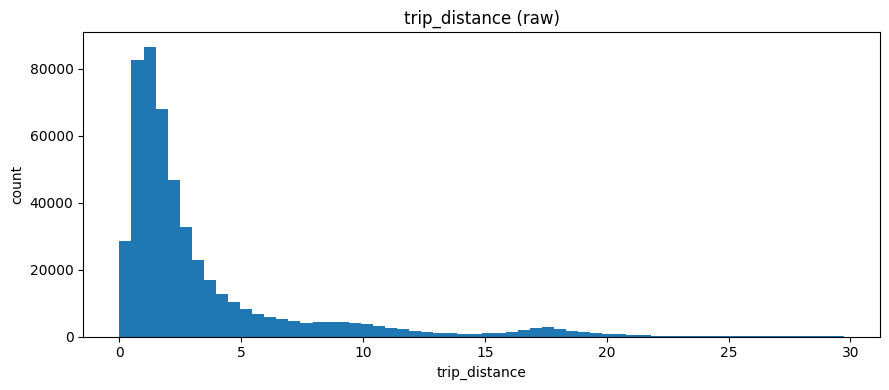

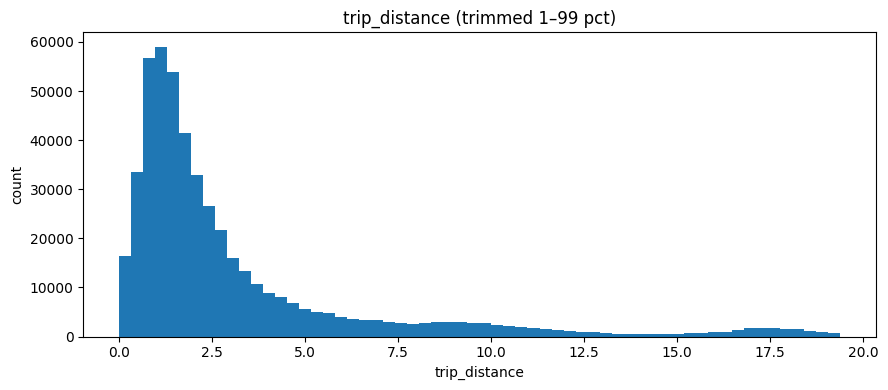

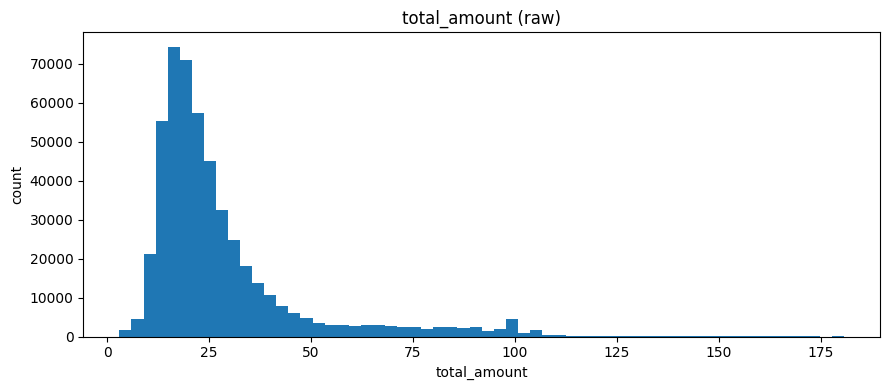

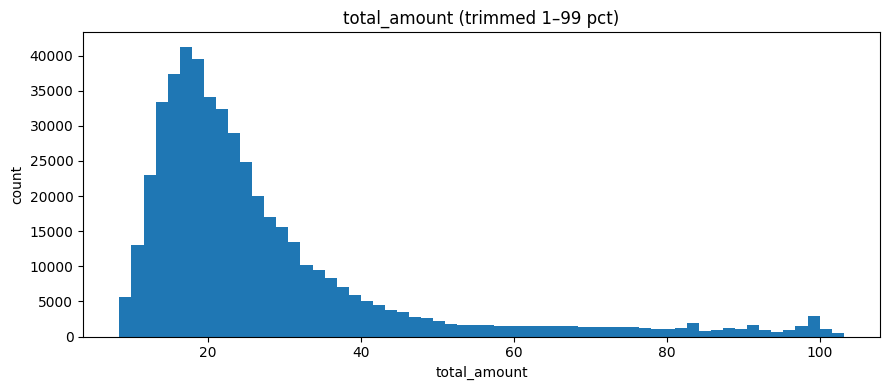

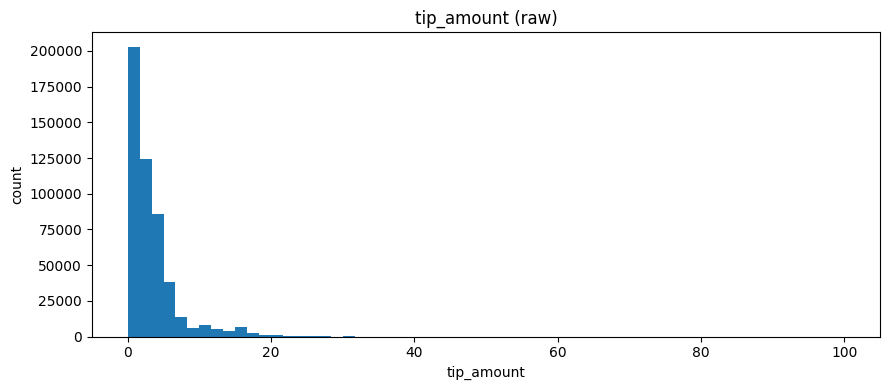

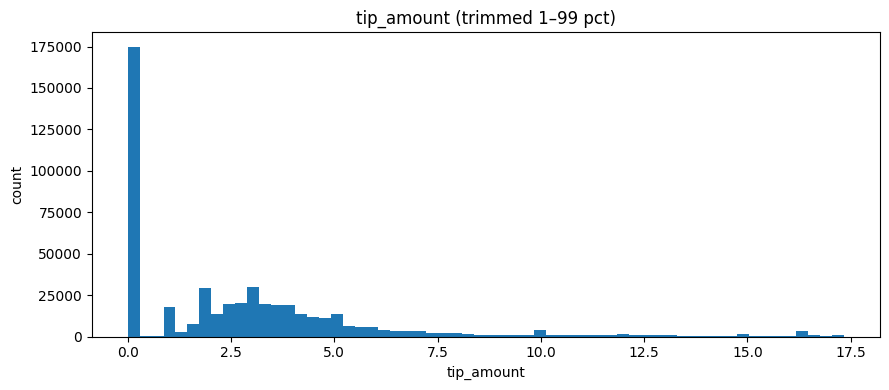

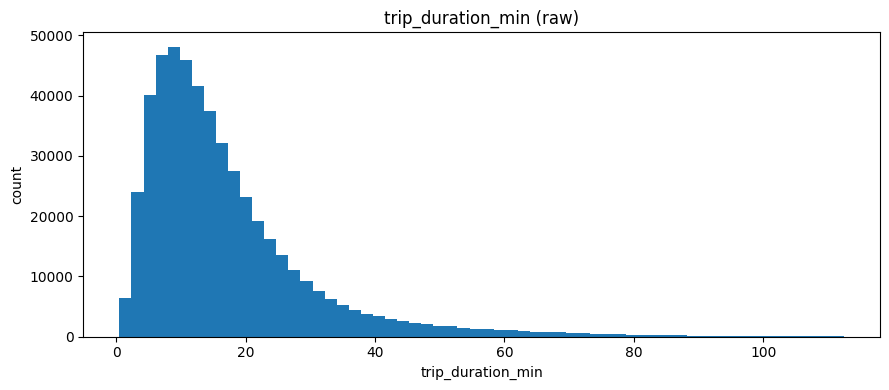

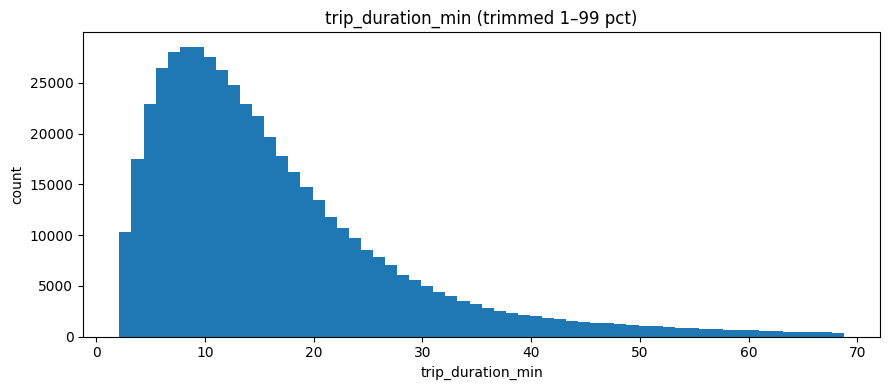

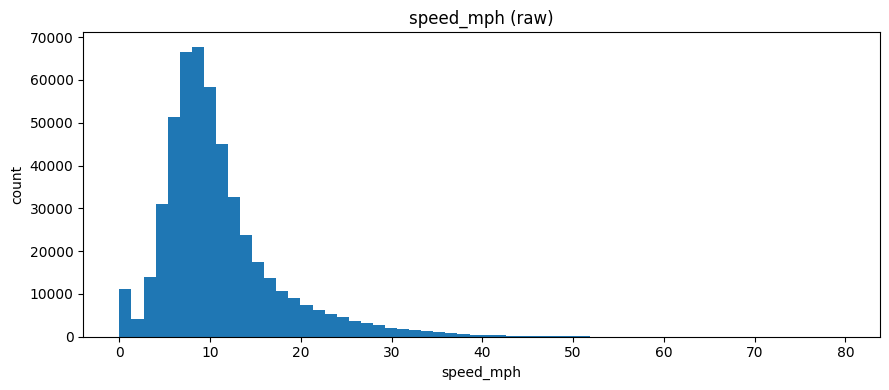

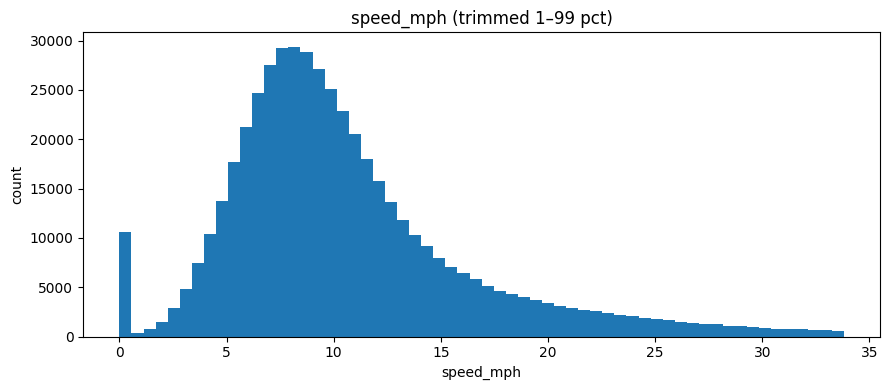

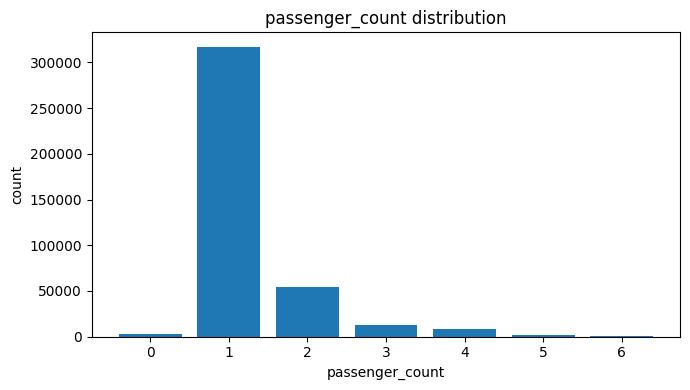

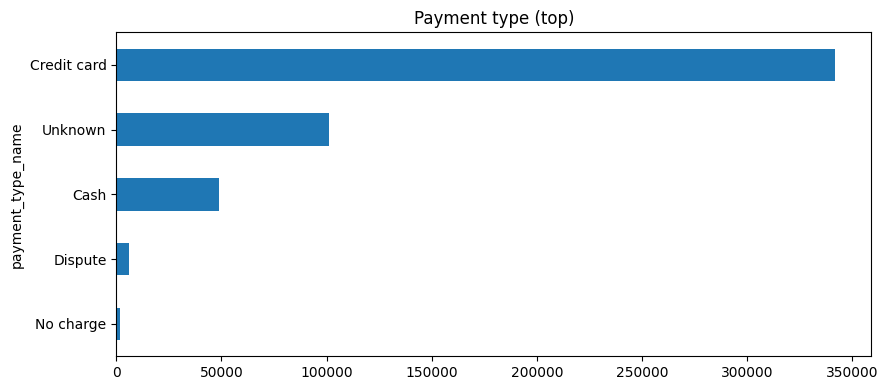

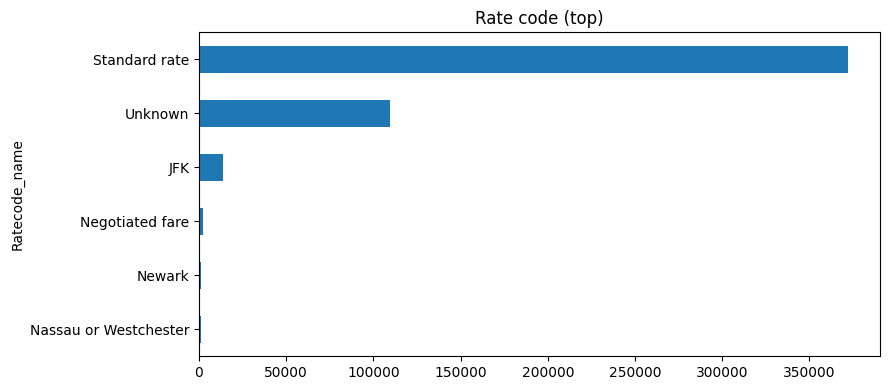

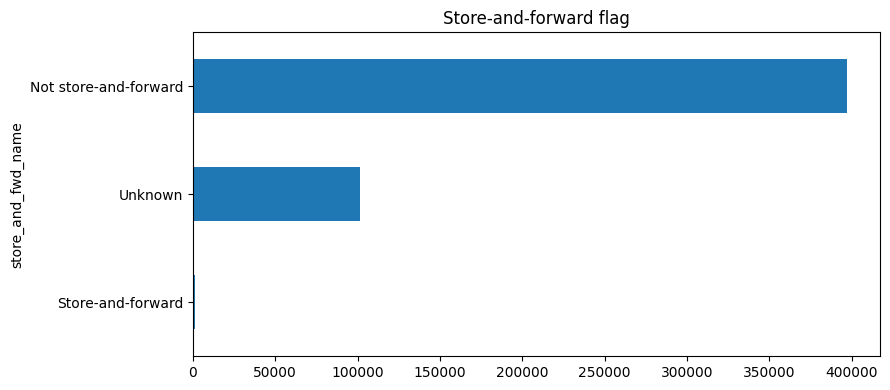

In [28]:
# Core distributions and top categories
import matplotlib.pyplot as plt

def hist_raw_and_trimmed(df, col, bins=60, q_low=0.01, q_high=0.99):
    x = df[col].dropna()
    if len(x) == 0:
        print(f"{col}: no data")
        return

    # Raw
    plt.figure(figsize=(9,4))
    plt.hist(x, bins=bins)
    plt.title(f"{col} (raw)")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    # Trimmed
    lo, hi = x.quantile(q_low), x.quantile(q_high)
    x_trim = x[(x >= lo) & (x <= hi)]
    plt.figure(figsize=(9,4))
    plt.hist(x_trim, bins=bins)
    plt.title(f"{col} (trimmed {q_low*100:.0f}–{q_high*100:.0f} pct)")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

def top_bar(df, col, n=15, title=None):
    """quick top-N barh."""
    if col not in df.columns:
        return
    vc = df[col].value_counts(dropna=False).head(n)
    plt.figure(figsize=(9,4))
    vc.sort_values().plot(kind="barh")
    plt.title(title or f"Top {n}: {col}")
    plt.tight_layout()
    plt.show()

# the core numeric distributions
for col in ["trip_distance","total_amount","tip_amount","trip_duration_min","speed_mph"]:
    if col in taxi_plot.columns:
        hist_raw_and_trimmed(taxi_plot, col)

# passenger count distributions
if "passenger_count" in taxi_plot.columns:
    pc = taxi_plot["passenger_count"].dropna().astype(int)
    plt.figure(figsize=(7,4))
    plt.bar(pc.value_counts().sort_index().index.astype(str), pc.value_counts().sort_index().values)
    plt.title("passenger_count distribution")
    plt.xlabel("passenger_count")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# Top categories
top_bar(taxi_plot, "payment_type_name", 10, "Payment type (top)")
top_bar(taxi_plot, "Ratecode_name", 10, "Rate code (top)")
top_bar(taxi_plot, "store_and_fwd_name", 5, "Store-and-forward flag")


- **Trip distance** is strongly right skewed. Meaning most rides are short, with a secondary bump in the high teens miles that might be outer borough or airport trips.
- **Total amount** concentrates around common short fares (tens of dollars) with a long right tail. There is a secondary spike at 100.
- **Tip amount** shows common lack of tips or very small usual tips. Analysis on tips isnt nessacarily reliable as cash tips would likely not be accurately recorded.
- **Trip duration** peaks around short to moderate lengths (a couple minute to under 20 minutes)
- **Speed** These results make sense for a busy city such as NYC (single/low double digits)
- **Passenger count** is dominated by **1–2 passengers**; the presence of **0** indicates missing marked as 0.
- **Credit card** dominates recorded payments, while **“Unknown” payment type** is a substantial subset and is also where many other fields go missing.


### 8) Spatial & temporal patterns
- Trips by pickup hour / day-of-week
- Top pickup and dropoff boroughs/zones
- Most common OD pairs

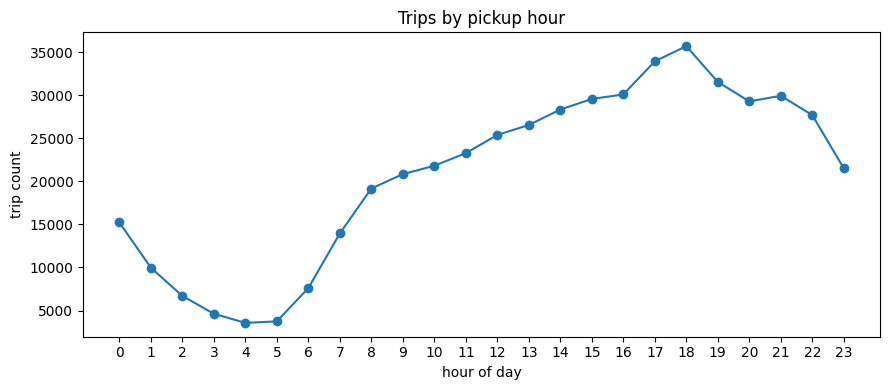

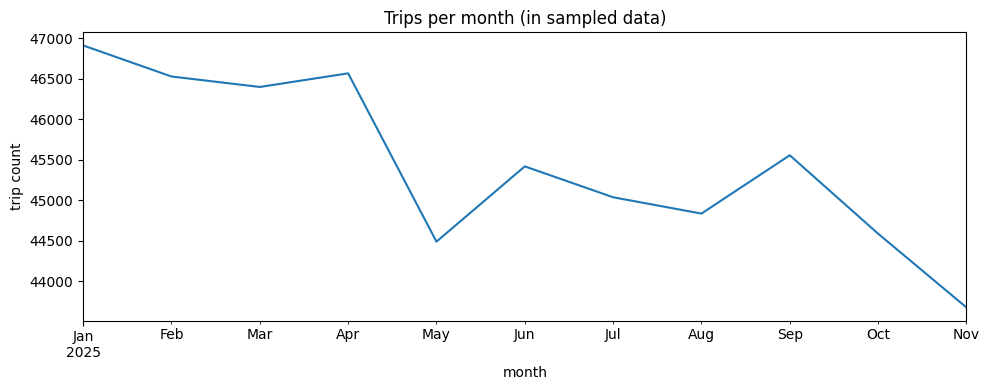

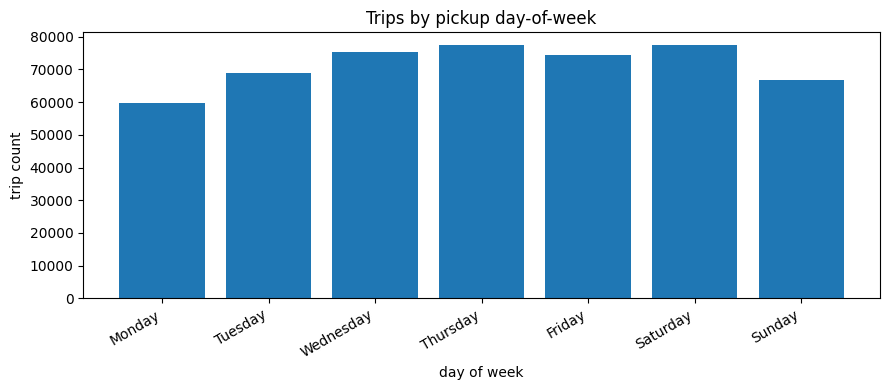

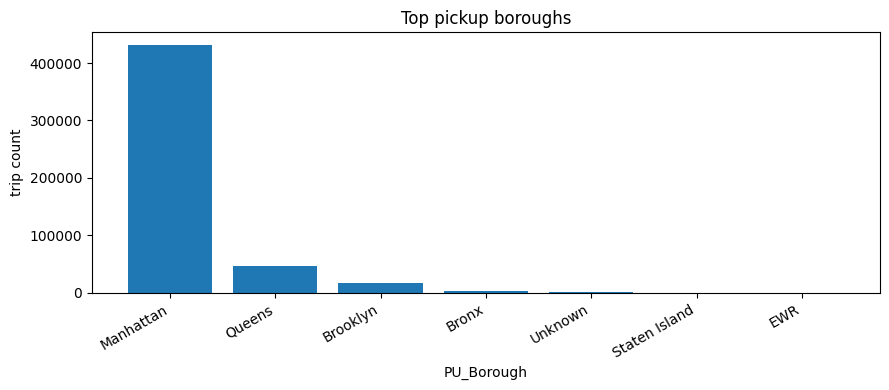

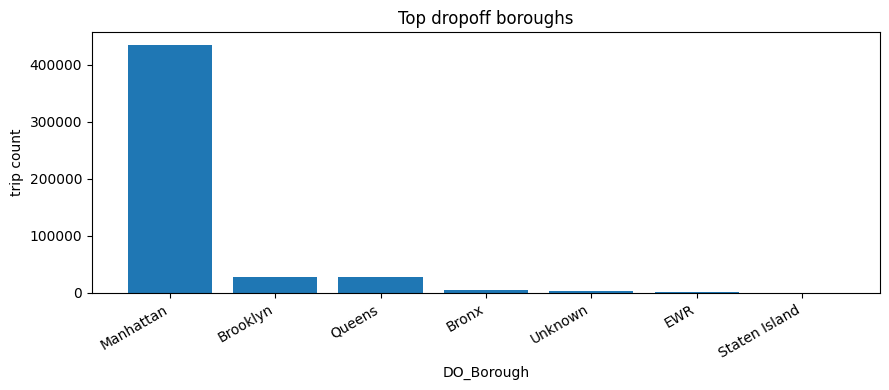

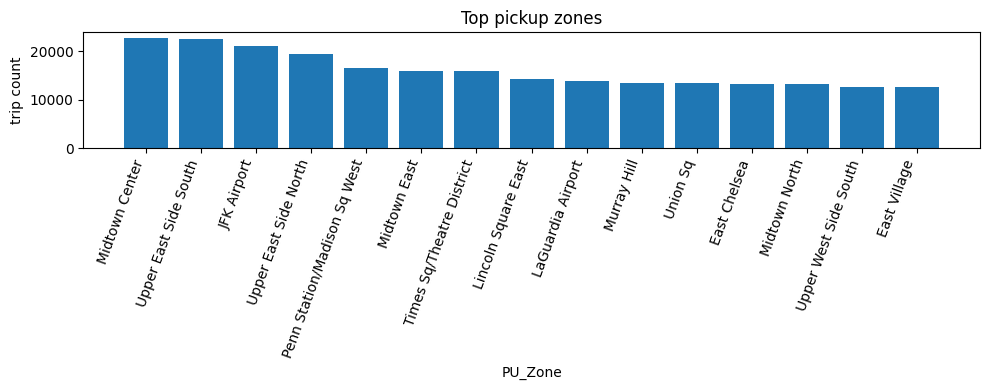

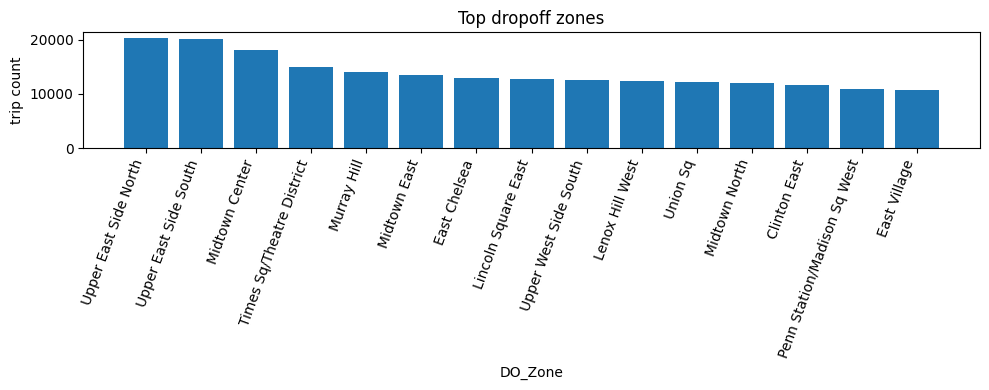

,PU_Zone,DO_Zone,trip_count
0,Upper East Side South,Upper East Side North,3227
1,Upper East Side North,Upper East Side South,2692
2,Upper East Side South,Upper East Side South,2173
3,Upper East Side North,Upper East Side North,2033
4,Midtown Center,Upper East Side South,1599
5,Upper East Side South,Midtown Center,1429
6,Midtown Center,Upper East Side North,1242
7,Upper East Side South,Midtown East,1151
8,Upper West Side South,Upper West Side North,1092
9,Lincoln Square East,Upper West Side South,1080


In [29]:
# trips by pickup hour
hour_counts = taxi_plot["pickup_hour"].value_counts().sort_index()
plt.figure(figsize=(9,4))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.title("Trips by pickup hour")
plt.xlabel("hour of day")
plt.ylabel("trip count")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

# trips by pickup month
if "pickup_month_ts" in taxi_plot.columns:
    month_counts = taxi_plot.groupby("pickup_month_ts").size()
    plt.figure(figsize=(10,4))
    month_counts.plot(kind="line")
    plt.title("Trips per month (in sampled data)")
    plt.xlabel("month")
    plt.ylabel("trip count")
    plt.tight_layout()
    plt.show()

# Trips by pickup (day of thhe week)
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = taxi_plot["pickup_dow"].value_counts().reindex(dow_order)
plt.figure(figsize=(9,4))
plt.bar(dow_counts.index, dow_counts.values)
plt.title("Trips by pickup day-of-week")
plt.xlabel("day of week")
plt.ylabel("trip count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# top pickup/dropoff boroughs
for col, title in [("PU_Borough","Top pickup boroughs"), ("DO_Borough","Top dropoff boroughs")]:
    if col not in taxi_plot.columns:
        continue
    vc = taxi_plot[col].fillna("Unknown").value_counts().head(10)
    plt.figure(figsize=(9,4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("trip count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# top pickup/dropoff zones
for col, title in [("PU_Zone","Top pickup zones"), ("DO_Zone","Top dropoff zones")]:
    if col not in taxi_plot.columns:
        continue
    vc = taxi_plot[col].fillna("Unknown").value_counts().head(15)
    plt.figure(figsize=(10,4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("trip count")
    plt.xticks(rotation=70, ha="right")
    plt.tight_layout()
    plt.show()

# most common zone pairs
od = (
    taxi_plot.dropna(subset=["PU_Zone","DO_Zone"])
            .groupby(["PU_Zone","DO_Zone"])
            .size()
            .sort_values(ascending=False)
            .head(20)
            .reset_index(name="trip_count")
)
display(od)


- pickups are lowest around **4–5am**, then rise sharply into the morning, with the largest peak in the **early evening**. This is fits common working hours.
- **Day of the week:** trips are higher mid/late week and on **Saturday**, while **Sunday/Monday** are lower.
- both pickups and dropoffs are dominated by **Manhattan**, with **Queens** next. Most likely amplified by airports.  
- The top zones include Midtown/UES areas and major transit/airport zones.
- the most frequent origin/destination pairs are largely within Manhattan, this indicates that a large fraction of trips are within a single bourough.
- These patterns suggest using zone level aggregation for later mining/modeling.


### 9) Missingness patterns (by payment type, vendor, time, geography)

Columns with missing values: ['passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', 'Airport_fee', 'PU_Borough', 'PU_Zone', 'PU_service_zone', 'DO_Borough', 'DO_Zone', 'DO_service_zone', 'speed_mph', 'tip_rate']


,missing_pct
RatecodeID,19.99
passenger_count,19.99
store_and_fwd_flag,19.99
congestion_surcharge,19.99
Airport_fee,19.99
speed_mph,1.13
DO_service_zone,0.68
DO_Borough,0.44


,RatecodeID,passenger_count,store_and_fwd_flag,congestion_surcharge,Airport_fee,speed_mph,DO_service_zone,DO_Borough
payment_type_name,,,,,,,,
Cash,0.0,0.0,0.0,0.0,0.0,1.56,1.16,0.76
Credit card,0.0,0.0,0.0,0.0,0.0,1.40,0.71,0.45
Dispute,0.0,0.0,0.0,0.0,0.0,0.40,1.36,1.24
No charge,0.0,0.0,0.0,0.0,0.0,2.39,1.95,1.07
Unknown,100.0,100.0,100.0,100.0,100.0,0.01,0.25,0.21


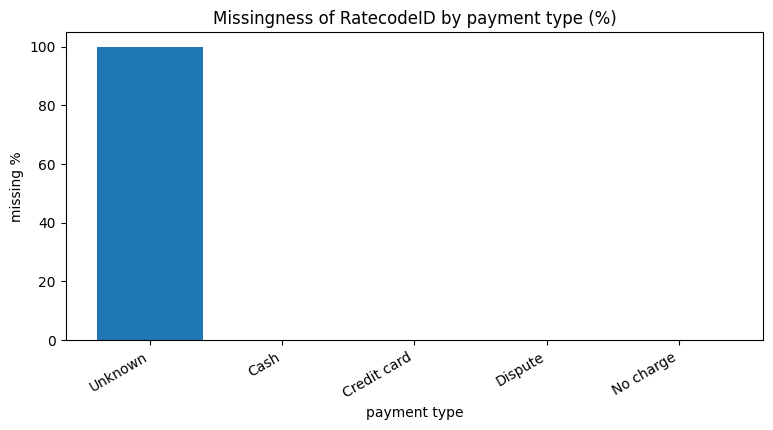

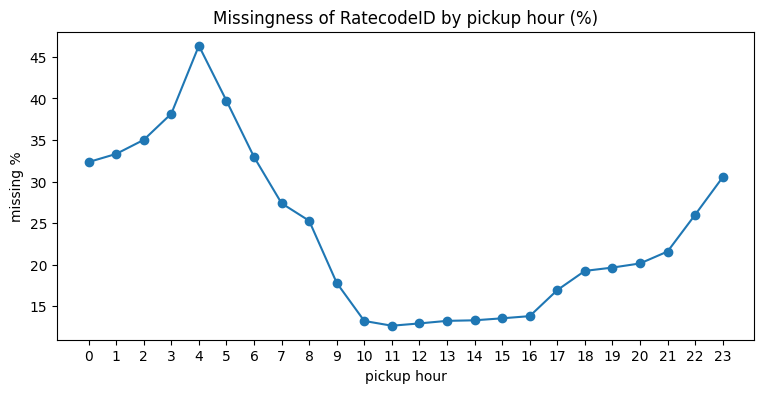

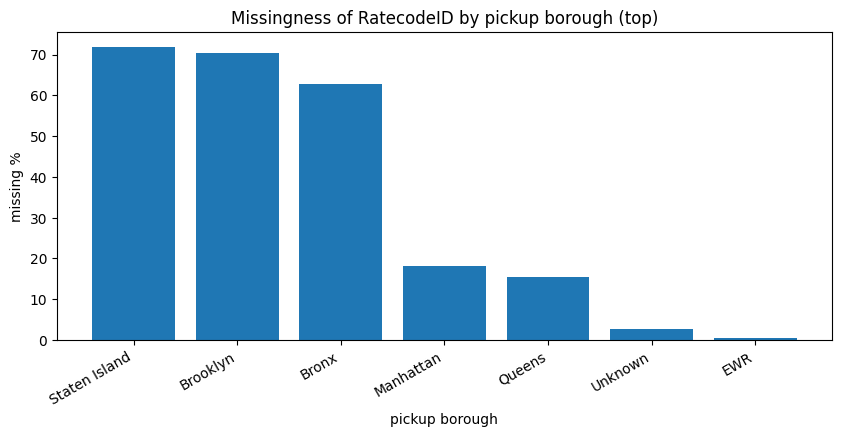

In [30]:
# Columns with any missing values (after cleaning)
missing_cols = [c for c in taxi.columns if taxi[c].isna().any()]
print("Columns with missing values:", missing_cols)

# highest-missing numeric columns
top_missing = (
    taxi.isna().mean()
       .sort_values(ascending=False)
       .head(8)
)
display((top_missing * 100).round(2).to_frame("missing_pct"))

focus_cols = list(top_missing.index)

# by payment type
miss_by_pay = (
    taxi.groupby("payment_type_name")[focus_cols]
        .apply(lambda g: g.isna().mean() * 100)
        .round(2)
        .sort_index()
)
display(miss_by_pay)

# plot missingness for the single highest missing column by payment type
most_missing_col = top_missing.index[0]
tmp = (taxi.groupby("payment_type_name")[most_missing_col]
          .apply(lambda s: s.isna().mean()*100)
          .sort_values(ascending=False))

plt.figure(figsize=(9,4))
plt.bar(tmp.index.astype(str), tmp.values)
plt.title(f"Missingness of {most_missing_col} by payment type (%)")
plt.xlabel("payment type")
plt.ylabel("missing %")
plt.xticks(rotation=30, ha="right")
plt.show()

# by pickup hour
tmp2 = (taxi.groupby("pickup_hour")[most_missing_col]
           .apply(lambda s: s.isna().mean()*100)
           .sort_index())

plt.figure(figsize=(9,4))
plt.plot(tmp2.index, tmp2.values, marker="o")
plt.title(f"Missingness of {most_missing_col} by pickup hour (%)")
plt.xlabel("pickup hour")
plt.ylabel("missing %")
plt.xticks(range(0,24))
plt.show()

# by pickup borough
if "PU_Borough" in taxi.columns:
    tmp3 = (taxi.groupby(taxi["PU_Borough"].fillna("Unknown"))[most_missing_col]
               .apply(lambda s: s.isna().mean()*100)
               .sort_values(ascending=False)
               .head(12))

    plt.figure(figsize=(10,4))
    plt.bar(tmp3.index.astype(str), tmp3.values)
    plt.title(f"Missingness of {most_missing_col} by pickup borough (top)")
    plt.xlabel("pickup borough")
    plt.ylabel("missing %")
    plt.xticks(rotation=30, ha="right")
    plt.show()


- In the cleaned data, the top missing fields are still the same five (`RatecodeID`, `passenger_count`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`).
- Missingness is **not random**. By payment type, the “Unknown” group shows **100% missing**.  
This likely means we should **filter out** `payment_type = Unknown` for analyses that require these fields
- Missingness also varies with **pickup hour** (highest in the early hours) and by **pickup borough** (very high percentages in low trip boroughs like Staten Island).


### 10) Bias / limitations

- **Coverage bias:** Yellow taxi trips are only a fraction of total transit and excludes ride share such as UBER/Lyft.
- **Tips field bias:** `tip_amount` is typically recorded for **credit card** trips, but likely unreliable for cashh tips, so tip statistics by payment type can be misleading.
- `PULocationID`/`DOLocationID` are taxi zones, not exact coordinates. Conclusions depend on zone boundaries.
- **Outliers/record errors:** Trip duration, distance, and fares can contain data entry errors. Filters change reported averages.


## (E) Initial insights and direction

### What the EDA suggests
**Data scope used for thhis report:** `DATA_START=2025-01`, `DATA_END=2025-11`, with `SAMPLE_ROWS_PER_MONTH=1,500,000` (This notebook is large but sampled).

**Cleaning:**
- **Loaded 16,500,000** trips (sampled across 11 months).
- **After basic cleaning there were 15,467,200** trips (**1,032,800 dropped**, 6.3%).  
  The removals are driven by basic constraints (e.g., negative money fields, invalid passenger counts, negative distances, and a small number of timing issues).

**Outliers / “typical trip” vs tail**
- The filtered set keeps **15,117,731** trips and drops **349,469** (2.3% of cleaned), with the biggest filter enforced being a duration window of 0.5 to 240 minutes.  
  This indicates that a non trivial “tail” exists and is worth analyzing separately.

**Missingness is structured**
- The same five columns have substantial missingness: **23.28%** missing in the raw sample and **19.99%** missing after cleaning (`passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`).
- Missingness is strongly associated with `payment_type = "Unknown"` (these fields are 100% missing there), and also varies by time-of-day and borough.  
  Conclusion: for models using these fields, we should most likely **exclude** the “Unknown payment type” subset.

**Behavioral patterns visible in plots**
- Trips are mostly short (distance + duration are right-skewed), speeds cluster at typical busy city speeds, and Manhattan dominates pickups and dropoffs.  
- Airports and major hubs appear in top zones, and top pairs are mostly within Manhattan.

### Hypotheses / RQs
1. **Graph structure of flows:** If we build a zone level OD flow graph (weighted by trip counts), do we observe clear communities, and do those communities change by hour/day?
2. **Anomalies in tail:** Can we automatically detect and characterize anomalous trips and separate data errors from “plausible” events using anomaly detection on thhe engineered features?
3. **Tip rate modeling:** For credit card trips, can we predict `tip_rate = tip_amount / total_amount` using trip features and do zone-graph features improve said model's performance?

### Beyond course technique to look into
**graph mining + spatiotemporal modeling**:
- Construct an OD flow graph with zones as nodes and weighted directed edges as trips.  
- Run community detection (to find mobility subregions) and/or node embeddings(to represent zones).  
- Use the graph features for tasks like zone-hour demand predictions, anomaly detection, andcomparing against non-graph baselines.


## (F) GitHub portfolio

- **GitHub link:** https://github.com/Malonedl/CSCE676-TLC-Trip-Record-Data

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://arxiv.org/abs/1707.01926 : Spatiotemporal forecasting
- https://arxiv.org/abs/1802.08714 : Demand prediction
- TLC data info:
    - https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
    - https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf
    - https://data.cityofnewyork.us/Transportation/NYC-Taxi-Zones/8meu-9t5y/about_data
    - https://www.nyc.gov/assets/tlc/downloads/pdf/trip_record_user_guide.pdf
    - https://d37ci6vzurychx.cloudfront.net/
- https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html : reading parquets
- https://pandas.pydata.org/docs/reference/api/pandas.merge.html : info on pandas merging
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://numpy.org/doc/2.1/reference/generated/numpy.quantile.html

3. AI Tools:
- ChatGPT:
    - I aked gpt for a list of interesting data sets to give me a starting point. This one was not in the list.
    - I asked gpt to walk me through on how some of the feature engineering should work for speed, time of the week, hour, and joining pickup/dropoff lookup table by location IDs.
    - I asked gpt to review the quantile trimming I did.

- Google Colab in line gen complete for line completions

```

# Project Checkpoint 2: Research Question Formation

**Dataset:** NYC TLC Yellow Taxi Trip Record Data (Jan–Nov 2025)  
**Student:** Dan Malone
**Course:** CSCE 676  
**GitHub:** https://github.com/Malonedl/CSCE676-TLC-Trip-Record-Data

## 1. Project Scope

**Dataset:** NYC TLC Yellow Taxi trip records, January–November 2025 (~15.5M cleaned trips across 263 taxi zones, sampled at 1.5M rows/month).

**EDA findings:** Trips are short and right-skewed (distance, duration, fare.) Manhattan dominates pickup and dropoffs with airports as secondary hubs. Around 350K outlier trips (2.3%) were trimmed by my duration rules. Five columns show ~20% missingness tied to `payment_type = "Unknown"`. The tip amounts are only reliable for credit card trips. And trip volume varies by hour and day of the week.

**Course techniques:** Clustering (k-means, DBSCAN), graph mining (PageRank, Personalized PageRank community detection), supervised learning (Gradient-Boosted Decision Trees / XGBoost)  
**External technique:** Spatiotemporal demand forecasting. This involves predicting zone and hour trip demand using time-series or sequence-based methods not covered in the course.


## 2. Research Questions


### RQ1: Do taxi zones form distinct communities in the origin-destination flow graph, and does that community structure change throughout the day?

| | |
|---|---|
| **Data mining task** | Graph mining/community detection |
| **Algorithms** | PageRank (course), Personalized PageRank sweep (course) |
| **Evaluation criteria** | geographic coherence vs. borough boundaries; stability across time of day slices |

 Checkpoint 1's EDA showed Manhattan core and airport hubs via raw trip counts, but did not examine the relational flow structure between zones. Building a weighted directed graph (zones = nodes, trip counts = edge weights) and running community detection to see whether zones group into meaningful sub-regions beyond the five-borough partition.



### RQ2: Can density based clustering identify and characterize distinct anomaly types among outlier trips, and how do those clusters compare to the heuristic outlier rules used in checkpoint 1?

| | |
|---|---|
| **Data mining task** | Clustering and anomaly detection |
| **Algorithms** | k-means (course), DBSCAN (course) |
| **Evaluation criteria** | Silhouette score and overlap comparison (DBSCAN noise vs. CP1 heuristic outliers)|

 In checkpoint 1 I removed around 350K trips using a 0.5–240 minute duration window and noted that this tail likely contains a mix of data errors and genuinely unusual trips. I want to use clustering to let the data define what is anomalous and separate the outliers into sub groups instead of a single bin.



### RQ3: Can a spatiotemporal demand forecasting model predict zone-hour trip counts more accurately than a baseline that ignores temporal patterns?

| | |
|---|---|
| **Data mining task** | Spatiotemporal demand forecasting (**external**) + supervised regression |
| **Algorithms** | Prophet or ARIMA time-series model (**external**); XGBoost with zone features (course) |
| **Evaluation criteria** | RMSE and MAE on held out future time periods; comparison of time-series model vs. XGBoost baseline; whether adding graph features (e.g., PageRank score, community membership) improves predictions |

 For each taxi zone and each hour, how many trips will originate there? This is a problem that requires time-series methods not seemingly covered in the course. The graph features from RQ1 (community membership, PageRank) can naturally be involved in improving the predictions.


### RQ-to-Method Mapping Table

| | RQ1: Zone Communities | RQ2: Trip Anomaly Profiles | RQ3: Demand Forecasting |
|---|---|---|---|
| **Technique type** | Course | Course | **External** + Course |
| **Course algorithms** | PageRank, PPR sweep | k-means, DBSCAN | XGBoost (tabular baseline) |
| **External algorithms** | none | none | **Prophet / ARIMA** |
| **Key features** | Zone-to-zone trip counts, time-of-day slices | duration, distance, speed, fare, hour, borough | Zone-hour trip counts, lagged demand, hour/dow, zone PageRank, community ID |
| **Evaluation** | Conductance, geographic coherence | Silhouette, DBSCAN-vs-heuristic overlap | RMSE / MAE on future time periods |
| **Baseline** | Naive borough grouping | CP1 quantile-based outlier rules | XGBoost without time-series component or graph features |


### Extra EDA for RQ1

Checkpoint 1 Section 8 already showed the top-20 OD zone pairs, top pickup/dropoff boroughs, and top pickup/dropoff zones. No additional EDA is needed here.

### Extra EDA for RQ2


Outlier trips: 308,386  (2.0% of pre-filter data)

Outlier type breakdown:
outlier_type
near_zero_duration    300701
extreme_duration        5474
impossible_speed        2102
other                    109


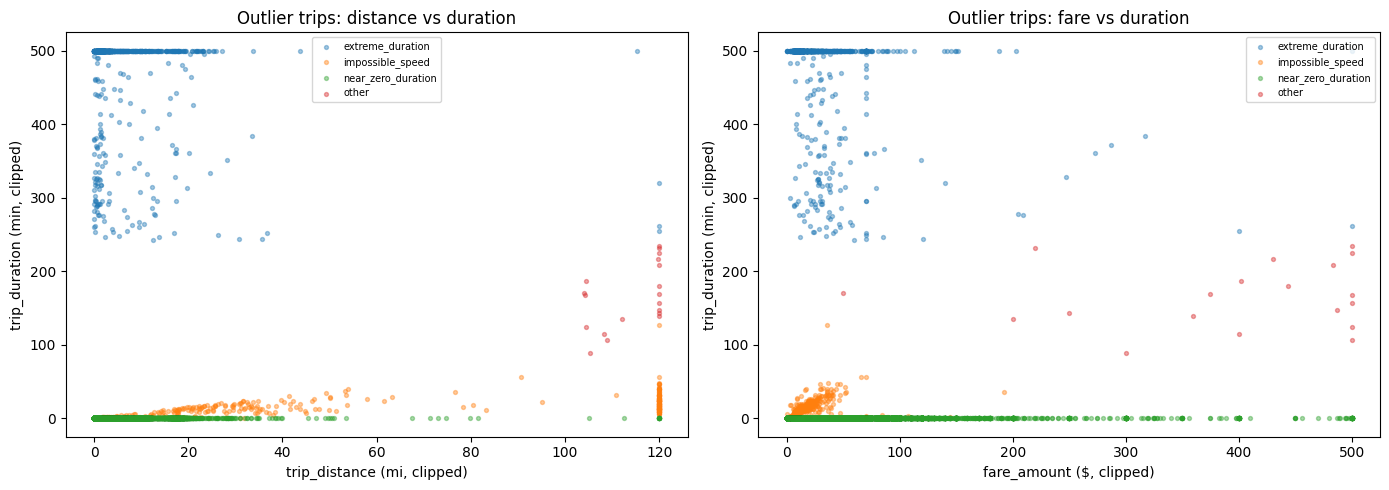

In [31]:
# Checking if the tail contains distict sub groups
core_cols = ["trip_duration_min", "trip_distance", "fare_amount", "total_amount"]
taxi_with_core = taxi.dropna(subset=core_cols).copy()

kept_mask = (
    taxi_with_core["trip_duration_min"].between(0.5, 240)
    & taxi_with_core["trip_distance"].between(0, 100)
    & (taxi_with_core["speed_mph"].between(0, 80) | taxi_with_core["speed_mph"].isna())
    & (taxi_with_core["fare_amount"] >= 0)
    & (taxi_with_core["total_amount"] >= 0)
)

outliers = taxi_with_core[~kept_mask].copy()
print(f"Outlier trips: {len(outliers):,}  "
      f"({len(outliers)/len(taxi_with_core)*100:.1f}% of pre-filter data)")

# label them by heuristic type
conditions = [
    (outliers["trip_duration_min"] < 0.5, "near_zero_duration"),
    (outliers["trip_duration_min"] > 240, "extreme_duration"),
    ((outliers["trip_distance"] == 0) & (outliers["fare_amount"] > 5), "zero_dist_high_fare"),
    (outliers["speed_mph"].fillna(0) > 80, "impossible_speed"),
    (outliers["fare_amount"] < 0, "negative_fare"),
    (outliers["total_amount"] < 0, "negative_total"),
]

outliers["outlier_type"] = "other"
for cond, label in conditions:
    outliers.loc[cond & (outliers["outlier_type"] == "other"), "outlier_type"] = label

print("\nOutlier type breakdown:")
print(outliers["outlier_type"].value_counts().to_string())

# Scatter plots
sample = outliers.sample(min(50_000, len(outliers)), random_state=412)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for otype, grp in sample.groupby("outlier_type"):
    axes[0].scatter(grp["trip_distance"].clip(0, 120),
                    grp["trip_duration_min"].clip(-5, 500),
                    label=otype, alpha=0.4, s=8)
axes[0].set_xlabel("trip_distance (mi, clipped)")
axes[0].set_ylabel("trip_duration (min, clipped)")
axes[0].set_title("Outlier trips: distance vs duration")
axes[0].legend(fontsize=7)

for otype, grp in sample.groupby("outlier_type"):
    axes[1].scatter(grp["fare_amount"].clip(-50, 500),
                    grp["trip_duration_min"].clip(-5, 500),
                    label=otype, alpha=0.4, s=8)
axes[1].set_xlabel("fare_amount ($, clipped)")
axes[1].set_ylabel("trip_duration (min, clipped)")
axes[1].set_title("Outlier trips: fare vs duration")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

negative_fare, negative_total, and zero_dist_high_fare don't appear beacause checkpoint 1's cleaning removed negative fares and totals. The outlier tail is dominated by near_zero_duration trips (~97%).

### Extra EDA for RQ3

Zone-hour rows: 945,836
Unique zones: 262
Date range: 2025-01-01 to 2025-11-30


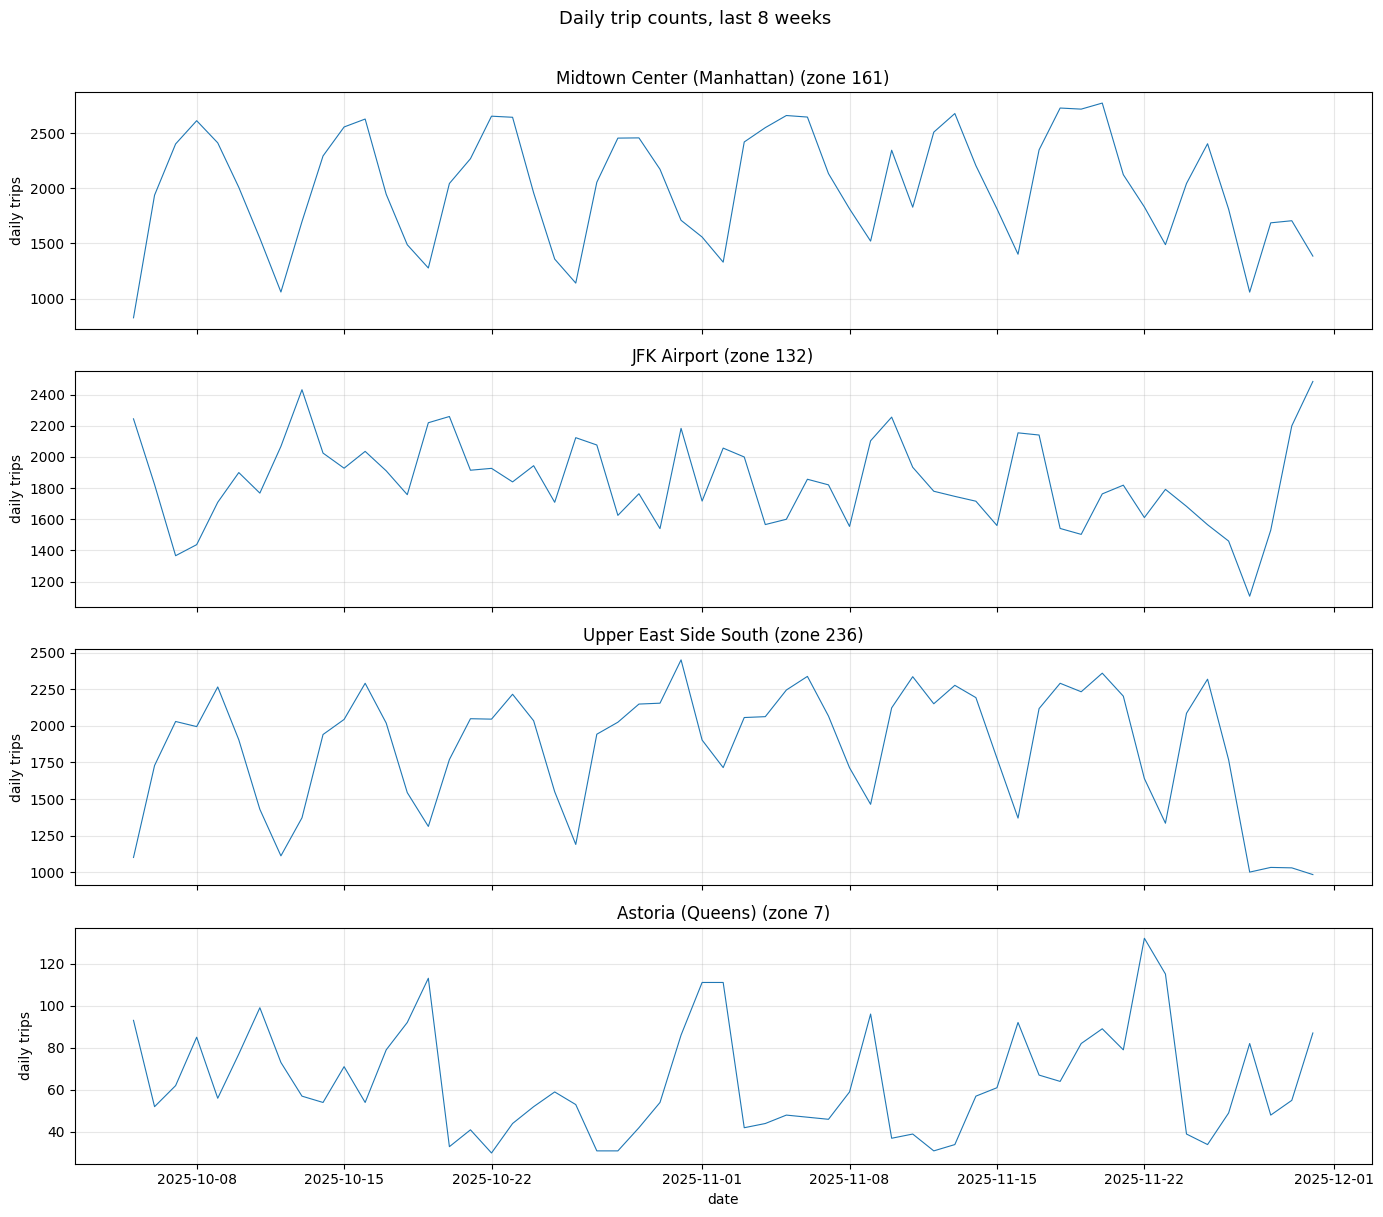

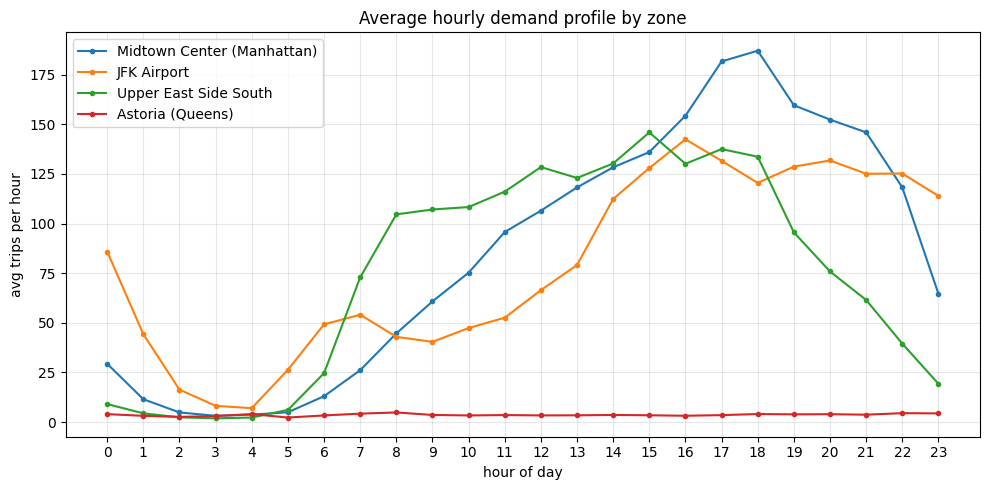

In [46]:
#If individual zones have distinct, repeating temporal patterns, time series shhould be a good fit

# zone × date × hour
zone_hour = (
    taxi_eda
    .groupby(["PULocationID", "pickup_date", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)
# convert to datetime for plotting
zone_hour["pickup_date"] = pd.to_datetime(zone_hour["pickup_date"])

zone_hour = zone_hour[zone_hour["pickup_date"].between("2025-01-01", "2025-11-30")]


print(f"Zone-hour rows: {len(zone_hour):,}")
print(f"Unique zones: {zone_hour['PULocationID'].nunique()}")
print(f"Date range: {zone_hour['pickup_date'].min().date()} to "
      f"{zone_hour['pickup_date'].max().date()}")

example_zones = {
    "Midtown Center (Manhattan)": 161,
    "JFK Airport": 132,
    "Upper East Side South": 236,
    "Astoria (Queens)": 7,
}

# daily trip counts for last 8 weeks per zone
cutoff = zone_hour["pickup_date"].max() - pd.Timedelta(weeks=8)
recent = zone_hour[zone_hour["pickup_date"] >= cutoff]

fig, axes = plt.subplots(len(example_zones), 1,
                          figsize=(14, 3 * len(example_zones)), sharex=True)

for ax, (name, zone_id) in zip(axes, example_zones.items()):
    zdata = (
        recent[recent["PULocationID"] == zone_id]
        .groupby("pickup_date")["trip_count"]
        .sum()
        .sort_index()
    )
    ax.plot(zdata.index, zdata.values, linewidth=0.8)
    ax.set_ylabel("daily trips")
    ax.set_title(f"{name} (zone {zone_id})")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("date")
plt.suptitle("Daily trip counts, last 8 weeks", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# average hourly per zone
fig, ax = plt.subplots(figsize=(10, 5))
for name, zone_id in example_zones.items():
    hourly = (
        zone_hour[zone_hour["PULocationID"] == zone_id]
        .groupby("pickup_hour")["trip_count"]
        .mean()
        .sort_index()
    )
    ax.plot(hourly.index, hourly.values, marker="o", markersize=3, label=name)

ax.set_xlabel("hour of day")
ax.set_ylabel("avg trips per hour")
ax.set_title("Average hourly demand profile by zone")
ax.legend()
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Different zones have distinctly different demands. Midtown peaks sharply in the evening, JFK is slightly flatter across the day with midday rise, and the residential Astoria zone has lower rides. This confirms zone-level temporal patterns exist and motivates RQ3.

## 3. Motivation and Feasibility




### RQ1:

**Motivation:** Checkpoint 1 ranked zones by trip volume, but volume alone ignores which zones exchange traffic. Community detection on the OD flow graph could potentially reveal sub-regions. Comparing communities across time slices shows whether the taxi network changes by hour.

**Non-triviality:** The baseline is the five-boroughs. If detected communities simply reproduce borough boundaries, the analysis does not add much. I believe the communities will sub-divide the boroughs.

**Feasibility:** The graph has about 263 nodes. PageRank and PPR will run very quickly using `networkx`.

**Risk:** The graph may end being too dense if most zones connect to most others.

### RQ2:

**Motivation:** In checkpoint 1 I removed about 350K outlier trips using quantile rules that treat all outliers identically. This feels too rigid and clustering should be able to divide the outliers into sub groups.

**Non-triviality:** The heuristic rules don't adapt to context. For instance a 90 minute trip is normal for JFK but anomalous within a place like Midtown. DBSCAN should be able to capture this, and comparing its flagged set against the original heuristic set quantifies what each approach misses.

**Feasibility:** k-means scales quite well. DBSCAN would could be fairly expensive with this dataset so using stratified sampling might be needed per borough runs.

**Risk:** DBSCAN is sensitive to hyperparameters so a large sweep should be done.

### RQ3:

**Motivation:** My EDA showed clear hourly and day-of-week trip volume variation and showed Manhattan dominance with airport peaks. I want to verify if given a zone and an hour can I predict how many trips will originate from that space in the given hour.

**Non-triviality:** The course covers clustering and classification but does not cover time-series forecasting. Demand forecasting requires handling seasonality (daily + weekly cycles), temporal autocorrelation, and zone level variation. Using a time-series model as the external technique addresses these properties.

**Feasibility:** Facebook Prophet is a well-documented Python package that already handles daily/weekly seasonality. For 263 zones, we can fit per-zone Prophet models or aggregate into zone-clusters from RQ1. XGBoost provides the baseline using lagged features.

**Risks:** (1) fitting 263 separate Prophet models may be slow. Using cluster zones first can mitigation this by fitting one model per cluster. (2) If demand is highly noisy at the zone-hour level, forecasting accuracy may be limited, but comparing against the XGBoost baseline will quantify whether the time-series approach adds value.


RQ 1 Feasibility

Nodes: 262
Edges: 48,877
Sparsity (edges / max possible): 71.48%
Weakly connected: True
Strongly connected: False


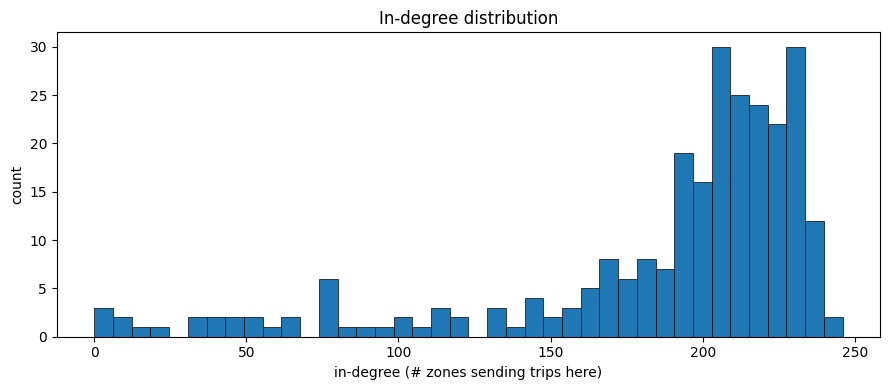

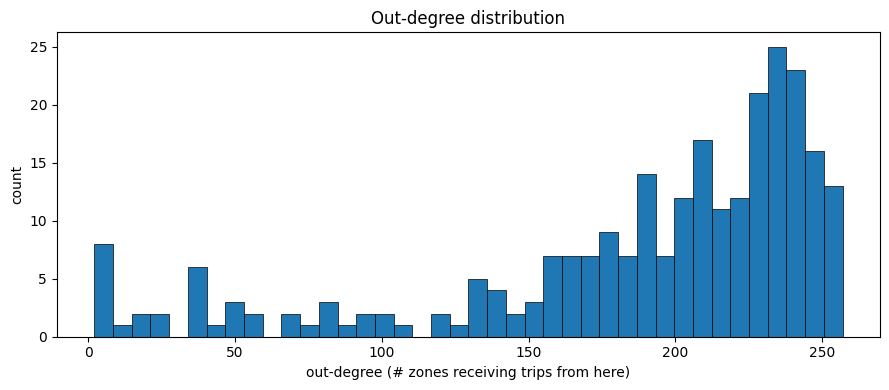

,LocationID,PageRank,Zone
0,236,0.024175,Upper East Side North
1,237,0.023658,Upper East Side South
2,161,0.021424,Midtown Center
3,170,0.017899,Murray Hill
4,230,0.017786,Times Sq/Theatre District
5,68,0.016770,East Chelsea
6,162,0.016759,Midtown East
7,239,0.016057,Upper West Side South
8,142,0.015965,Lincoln Square East
9,48,0.015276,Clinton East


In [34]:
# Confirm the graph is connected, not trivially dense, and has non uniform edge weights

od_all = (
    taxi_eda
    .groupby(["PULocationID", "DOLocationID"])
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

# build directed graph from OD pair count
G = nx.from_pandas_edgelist(
    od_all, "PULocationID", "DOLocationID",
    edge_attr="trip_count", create_using=nx.DiGraph()
)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
max_edges = n_nodes * (n_nodes - 1)
sparsity = n_edges / max_edges

print(f"Nodes: {n_nodes}")
print(f"Edges: {n_edges:,}")
print(f"Sparsity (edges / max possible): {sparsity:.2%}")
print(f"Weakly connected: {nx.is_weakly_connected(G)}")
print(f"Strongly connected: {nx.is_strongly_connected(G)}")

if not nx.is_weakly_connected(G):
    comps = list(nx.weakly_connected_components(G))
    print(f"Weakly connected components: {len(comps)}")
    print(f"Largest component size: {max(len(c) for c in comps)}")

# in degree distribution
in_deg = [d for _, d in G.in_degree()]
plt.figure(figsize=(9, 4))
plt.hist(in_deg, bins=40, edgecolor="black", linewidth=0.5)
plt.title("In-degree distribution")
plt.xlabel("in-degree (# zones sending trips here)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# out degree distribution
out_deg = [d for _, d in G.out_degree()]
plt.figure(figsize=(9, 4))
plt.hist(out_deg, bins=40, edgecolor="black", linewidth=0.5)
plt.title("Out-degree distribution")
plt.xlabel("out-degree (# zones receiving trips from here)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# PageRank sanity check
zone_id_to_name = zones.set_index("LocationID")["Zone"]

pr = nx.pagerank(G, weight="trip_count")
top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]

pr_df = pd.DataFrame(top_pr, columns=["LocationID", "PageRank"])
pr_df["Zone"] = pr_df["LocationID"].map(zone_id_to_name)
display(pr_df)


The graph is weakly connected but 71% dense, meaning most zones have at least one trip to most other zones. This shows edge-weight thresholding will be needed to see community structure before running PPR sweep. The PageRank top 10 matches the top pickup zones from checkpoint 1.

RQ 2 Feasibility

In [35]:
# Quick k-means on the outlier subset to see whether clusters have distinct subgroups

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat_cols = ["trip_distance", "trip_duration_min", "fare_amount", "speed_mph"]

# drop NaN rows
outlier_clean = outliers.dropna(subset=feat_cols).copy()
sample_n = min(50_000, len(outlier_clean))
outlier_sample = outlier_clean.sample(sample_n, random_state=412)

X = outlier_sample[feat_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"outlier sample size: {sample_n:,}")
print(f"features: {feat_cols}")
print()

# k means
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=412, n_init=10)
    outlier_sample["cluster"] = km.fit_predict(X_scaled)

    # cluster profiles
    profile = (
        outlier_sample
        .groupby("cluster")[feat_cols]
        .mean()
        .round(2)
    )
    sizes = outlier_sample["cluster"].value_counts().sort_index()

    print(f"--- k = {k} ---")
    print(f"Cluster sizes: {sizes.to_dict()}")
    display(profile)
    print()


outlier sample size: 50,000
features: ['trip_distance', 'trip_duration_min', 'fare_amount', 'speed_mph']

--- k = 3 ---
Cluster sizes: {0: 1566, 1: 48303, 2: 131}


,trip_distance,trip_duration_min,fare_amount,speed_mph
cluster,,,,
0,4.21,1411.11,22.70,0.20
1,47.62,4.68,41.86,148.37
2,113515.18,20.12,21.98,442005.87



--- k = 4 ---
Cluster sizes: {0: 29866, 1: 18437, 2: 134, 3: 1563}


,trip_distance,trip_duration_min,fare_amount,speed_mph
cluster,,,,
0,59.73,5.53,11.89,194.63
1,16.90,3.42,90.45,49.11
2,112504.34,20.37,22.07,435458.69
3,4.19,1412.19,22.15,0.20



--- k = 5 ---
Cluster sizes: {0: 29249, 1: 131, 2: 1563, 3: 356, 4: 18701}


,trip_distance,trip_duration_min,fare_amount,speed_mph
cluster,,,,
0,65.84,5.44,11.10,210.66
1,113515.18,20.12,21.98,442005.87
2,4.19,1412.19,22.15,0.20
3,18.01,37.44,447.29,85.38
4,19.69,3.00,82.29,52.12


Cluster 2 contains extreme junk records (speed > 400K mph, distance > 100K mi). Capping the features in the future will most likely be best due to the imbalance and extreme values.



RQ 3 Feasibility

Zone 236 (Upper East Side North) hourly series: 8,016 hours
mean hourly trips: 74.1
Std: 60.2


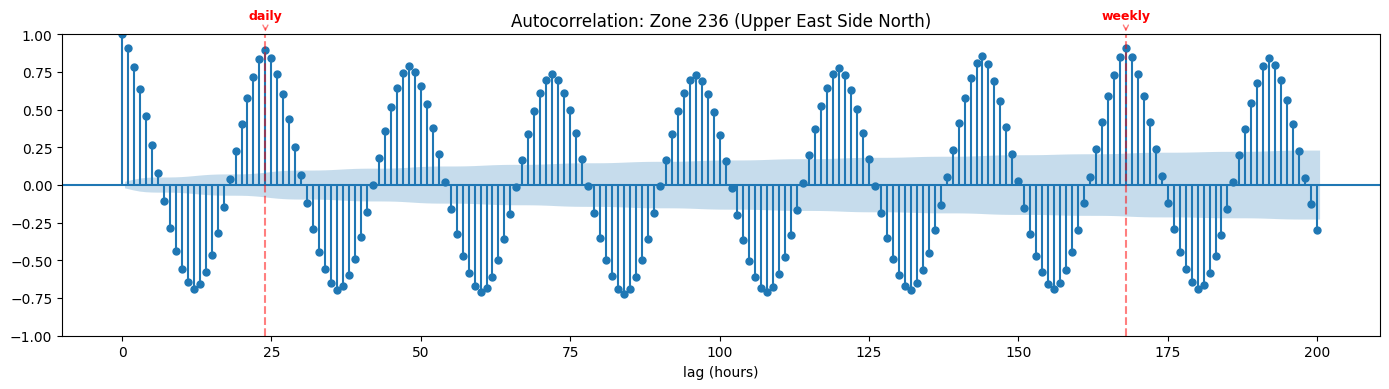


 zone level hourly demand stats (top 15 by mean):


,mean,std,count,Zone
PULocationID,,,,
237,86.56,65.03,7845,Upper East Side South
161,85.30,73.15,7929,Midtown Center
132,78.80,49.52,7961,JFK Airport
236,77.47,59.36,7664,Upper East Side North
186,61.90,36.70,7991,Penn Station/Madison Sq West
162,61.22,46.33,7915,Midtown East
230,59.98,44.71,8009,Times Sq/Theatre District
138,59.92,35.25,6868,LaGuardia Airport
142,55.46,40.04,7837,Lincoln Square East


In [40]:
# Check autocorrelation in zone hourly demand.

from statsmodels.graphics.tsaplots import plot_acf

# using a higher volume zone
# zone 236is Upper East Side South
test_zone = 236
test_zone_name = zone_id_to_name.get(test_zone, "Unknown")

# Build a complete hourly time series for this zone
zone_ts = (
    zone_hour[zone_hour["PULocationID"] == test_zone]
    .assign(datetime=lambda df: df["pickup_date"] + pd.to_timedelta(df["pickup_hour"], unit="h"))
    .set_index("datetime")["trip_count"]
    .sort_index()
)

# fill in missing hours with 0
full_idx = pd.date_range(zone_ts.index.min(), zone_ts.index.max(), freq="h")
zone_ts = zone_ts.reindex(full_idx, fill_value=0)

print(f"Zone {test_zone} ({test_zone_name}) hourly series: {len(zone_ts):,} hours")
print(f"mean hourly trips: {zone_ts.mean():.1f}")
print(f"Std: {zone_ts.std():.1f}")

# ACF plot
plt.figure(figsize=(14, 4))
ax = plt.gca()
plot_acf(zone_ts, lags=200, ax=ax, alpha=0.05)
ax.set_title(f"Autocorrelation: Zone {test_zone} ({test_zone_name})")
ax.set_xlabel("lag (hours)")
for lag, label in [(24, "daily"), (168, "weekly")]:
    ax.axvline(x=lag, color="red", linestyle="--", alpha=0.5)
    ax.annotate(label, xy=(lag, 1.0), xytext=(lag, 1.1),
                color="red", fontsize=9, ha="center", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="red", alpha=0.5),
                annotation_clip=False)
plt.tight_layout()
plt.show()

# Zone demand variance
zone_stats = (
    zone_hour
    .groupby("PULocationID")["trip_count"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)
zone_stats["Zone"] = zone_stats.index.map(zone_id_to_name)

print(f"\n zone level hourly demand stats (top 15 by mean):")
display(zone_stats.head(15).round(2))


The ACF graph shows strong peaks at lag 24 (daily) and lag 168 (weekly), confirming the demand series has dual seasonality which Prophet is designed to work well with. A large portion of zones have very low mean hourly demand , so these zones may need to be grouped before per-zone tests.

## 4. Methodological Planning



### Algorithms

**Course algorithms:**

| Algorithm  | Project application |
|---|---|
| PageRank | Rank zone importance in the OD graph |
| PPR sweep | Detect mobility communities per time slice |
| k-means |Discover trip-profile clusters |
| DBSCAN | Flag anomalies among trips |
| XGBoost | Demand forecasting baseline |

**External algorithm:**

| Algorithm | Source | Project application |
|---|---|---|
| Prophet | Taylor & Letham, 2018 (Facebook) | Time-series demand forecasting per zone with daily/weekly seasonality |

Prophet is an additive time-series model that decomposes a series into trend, seasonality (daily, weekly, yearly), and holiday effects. It is said to handle missing data very well, which will be good for the TLC data where some zone-hours have zero trips.

### Evaluation
| RQ | Metrics | Baseline | Evaluation |
|---|---|---|---|
| **RQ1** | Jaccard similarity, coconductance | EDA borough partitions | Communities have lower conductance than borough baselin. At least some sub-boroughs |
| **RQ2** | Silhouette score; DBSCAN noise count | CP1 heuristic outlier set | Silhouette > 0.3. DBSCAN finds anomaly sub-types the heuristic misses |
| **RQ3** | RMSE, MAE on future time periods | XGBoost with lagged demand + zone features | Prophet may reduce RMSE over XGBoost baseline; adding graph features (PageRank, community) improves predictions further |


### Data Splits and Preprocessing

- **Train/test split:** Jan–Aug 2025 for training, Sep–Nov 2025 for testing. This avoids data leakage.
- **Feature scaling:** StandardScaler on continuous features before k-means and DBSCAN.
- **Missingness:** Exclude `payment_type = "Unknown"` rows for analyses involving `passenger_count`, `RatecodeID`, `congestion_surcharge`, or `Airport_fee`. These fields are 100% missing for that group.
- **DBSCAN scaling:** Stratified sampling or per borough runs to reduce runtime.
- **RQ3 zero-fill:** Zone-hours with no trips are filled with 0 , since zero demand is valid for forecasting.

### Initial Method Runs

K-means elbow:

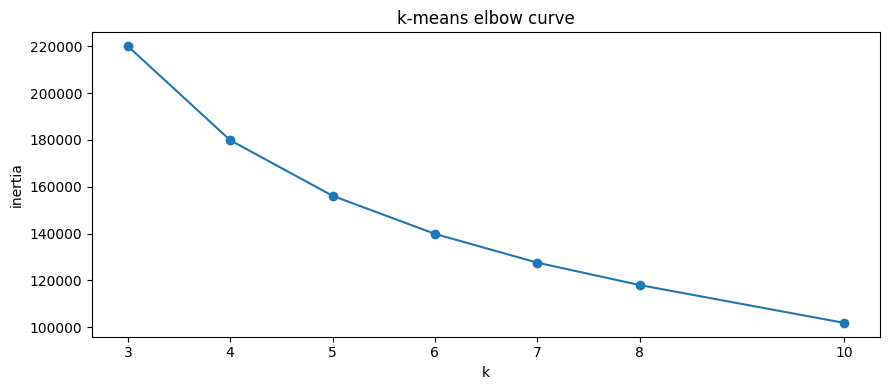

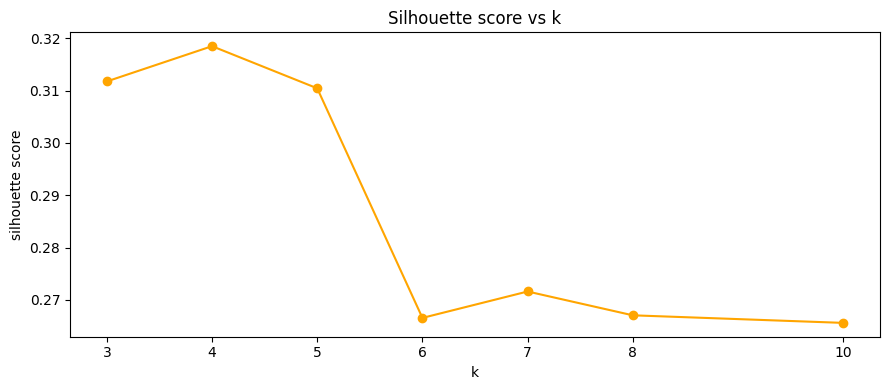

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

km_sample = taxi_eda.sample(100_000, random_state=412)
feat_cols = ["trip_distance", "trip_duration_min", "speed_mph", "fare_amount", "pickup_hour"]
X_scaled = StandardScaler().fit_transform(km_sample[feat_cols].dropna())

k_values = [3, 4, 5, 6, 7, 8, 10]
inertias, sils = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=412, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels, sample_size=20_000, random_state=412))

plt.figure(figsize=(9, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("k-means elbow curve")
plt.xlabel("k")
plt.ylabel("inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(k_values, sils, marker="o", color="orange")
plt.title("Silhouette score vs k")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.xticks(k_values)
plt.tight_layout()
plt.show()


The elbow curve flattens around k=6 and silhouette scores are highest at lower k values. 5-6 clusters should be a reasonable starting spot.

DBSCAN sweep:

In [42]:
from sklearn.cluster import DBSCAN

feat_cols_db = ["trip_distance", "trip_duration_min", "fare_amount", "speed_mph"]
db_sample = outliers.dropna(subset=feat_cols_db).sample(min(50_000, len(outliers)), random_state=412)
X_db = StandardScaler().fit_transform(db_sample[feat_cols_db])

results = []
for eps in [0.3, 0.5, 0.8, 1.0]:
    for ms in [10, 25, 50]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_db)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels) * 100
        results.append((eps, ms, n_clusters, noise_pct))

results_df = pd.DataFrame(results, columns=["eps", "min_samples", "clusters", "noise_pct"])
display(results_df)

,eps,min_samples,clusters,noise_pct
0,0.3,10,3,0.760
1,0.3,25,6,0.892
2,0.3,50,6,1.524
3,0.5,10,3,0.598
4,0.5,25,1,0.684
5,0.5,50,2,0.804
6,0.8,10,3,0.484
7,0.8,25,1,0.594
8,0.8,50,1,0.618
9,1.0,10,3,0.418


Noise percentages are low across all parameter combos, so DBSCAN assigns almost everything to clusters instead of flagging anomalies. This is likely because the outlier subset is already 97% near_zero_duration trips. Running DBSCAN with the full dataset will take more time but may produce better results in regards to noise.

Prophet on one zone:

Prophet RMSE (zone 236): 38.57
Mean actual: 76.52


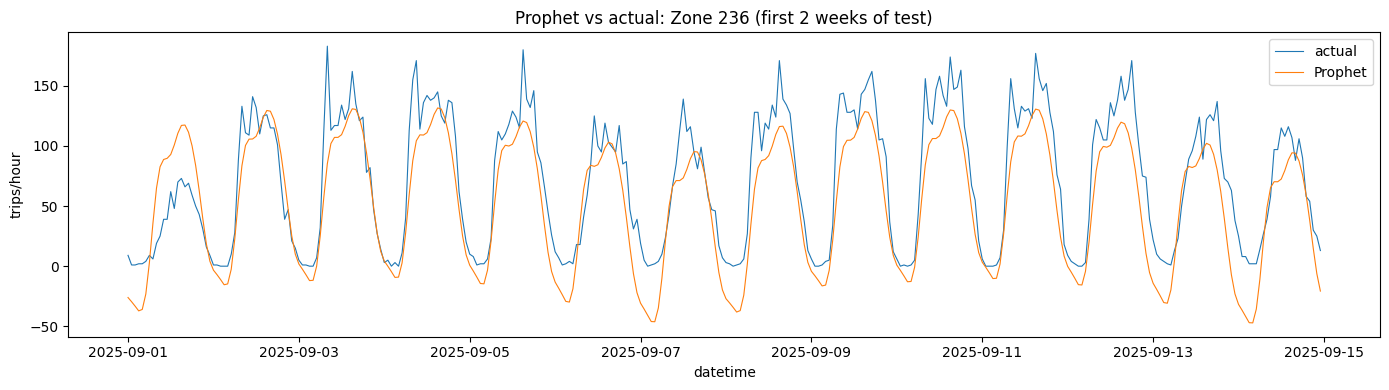

In [43]:
!pip install -q prophet
from prophet import Prophet

test_zone = 236 #upper east siude

# build Prophet df
prophet_df = (
    zone_hour[zone_hour["PULocationID"] == test_zone]
    .assign(ds=lambda df: df["pickup_date"] + pd.to_timedelta(df["pickup_hour"], unit="h"))
    .rename(columns={"trip_count": "y"})[["ds", "y"]]
    .sort_values("ds")
)
full_idx = pd.date_range(prophet_df["ds"].min(), prophet_df["ds"].max(), freq="h")
prophet_df = prophet_df.set_index("ds").reindex(full_idx, fill_value=0).reset_index().rename(columns={"index": "ds"})

# train/test split
train_cutoff = pd.Timestamp("2025-09-01")
train_df = prophet_df[prophet_df["ds"] < train_cutoff]
test_df = prophet_df[prophet_df["ds"] >= train_cutoff]

# fittting and predict
m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
m.fit(train_df)
forecast = m.predict(test_df[["ds"]])

eval_df = test_df.merge(forecast[["ds", "yhat"]], on="ds")
prophet_rmse = np.sqrt(((eval_df["y"] - eval_df["yhat"]) ** 2).mean())
print(f"Prophet RMSE (zone {test_zone}): {prophet_rmse:.2f}")
print(f"Mean actual: {eval_df['y'].mean():.2f}")

# Plot first 2 weeks
plot_mask = eval_df["ds"] < train_cutoff + pd.Timedelta(weeks=2)
plt.figure(figsize=(14, 4))
plt.plot(eval_df.loc[plot_mask, "ds"], eval_df.loc[plot_mask, "y"], label="actual", linewidth=0.8)
plt.plot(eval_df.loc[plot_mask, "ds"], eval_df.loc[plot_mask, "yhat"], label="Prophet", linewidth=0.8)
plt.title(f"Prophet vs actual: Zone {test_zone} (first 2 weeks of test)")
plt.xlabel("datetime")
plt.ylabel("trips/hour")
plt.legend()
plt.tight_layout()
plt.show()


Prophet has decent results on the small test matching the general shape.

XGBoost baseline:

In [44]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# same zone and df as prophet
xgb_df = prophet_df.copy()
xgb_df["hour"] = xgb_df["ds"].dt.hour
xgb_df["dow"] = xgb_df["ds"].dt.dayofweek
xgb_df["month"] = xgb_df["ds"].dt.month
xgb_df["lag_1h"] = xgb_df["y"].shift(1)
xgb_df["lag_24h"] = xgb_df["y"].shift(24)
xgb_df["lag_168h"] = xgb_df["y"].shift(168)
xgb_df = xgb_df.dropna()

feats = ["hour", "dow", "month", "lag_1h", "lag_24h", "lag_168h"]
train_mask = xgb_df["ds"] < train_cutoff

model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=412)
model.fit(xgb_df.loc[train_mask, feats], xgb_df.loc[train_mask, "y"], verbose=False)
y_pred = model.predict(xgb_df.loc[~train_mask, feats])
y_test = xgb_df.loc[~train_mask, "y"]

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"XGBoost RMSE (zone {test_zone}): {xgb_rmse:.2f}")
print(f"Prophet RMSE (zone {test_zone}): {prophet_rmse:.2f}")

XGBoost RMSE (zone 236): 15.95
Prophet RMSE (zone 236): 38.57


XGBoost (15.95) significantly outperforms Prophet (38.57) on this single-zone test. Prophet may need tuning, or the lag features give XGBoost an advantage.

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://facebook.github.io/prophet/ : Prophet documentation
- https://peerj.com/preprints/3190/ : Taylor & Letham, "Forecasting at Scale" (2018)
- https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html : NetworkX PageRank
- https://scikit-learn.org/stable/modules/clustering.html : scikit-learn clustering (k-means, DBSCAN)
- https://xgboost.readthedocs.io/ : XGBoost documentation
- TLC data sources (same as Checkpoint 1)
- https://en.wikipedia.org/wiki/PageRank : general pagerank info
- https://en.wikipedia.org/wiki/Time_series : general Time series info
- https://en.wikipedia.org/wiki/Autocorrelation : general autocorrelation info

3. AI Tools:
- ChatGPT: I used for research question structure and reviewing feasibility assessments, plot building, prophet information, a breakdown on autocorrelation/aggregration, and review on building the weighted graph.

4. Citations:
- Taylor, S.J. & Letham, B. (2018). Forecasting at Scale. The American Statistician, 72(1), 37-45.
```